# Figure 3 SOTA performance

/var/folders/1j/7pqn40651hvgyt1913gz84880000gn/T/ipykernel_45585/128891941.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  polar_ax1.set_xticklabels(['' for _ in range(len(labels_ret))], fontsize=fontsize_ticks)
/var/folders/1j/7pqn40651hvgyt1913gz84880000gn/T/ipykernel_45585/128891941.py:191: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  polar_ax2.set_xticklabels(['' for _ in range(len(labels_gen))], fontsize=fontsize_ticks)


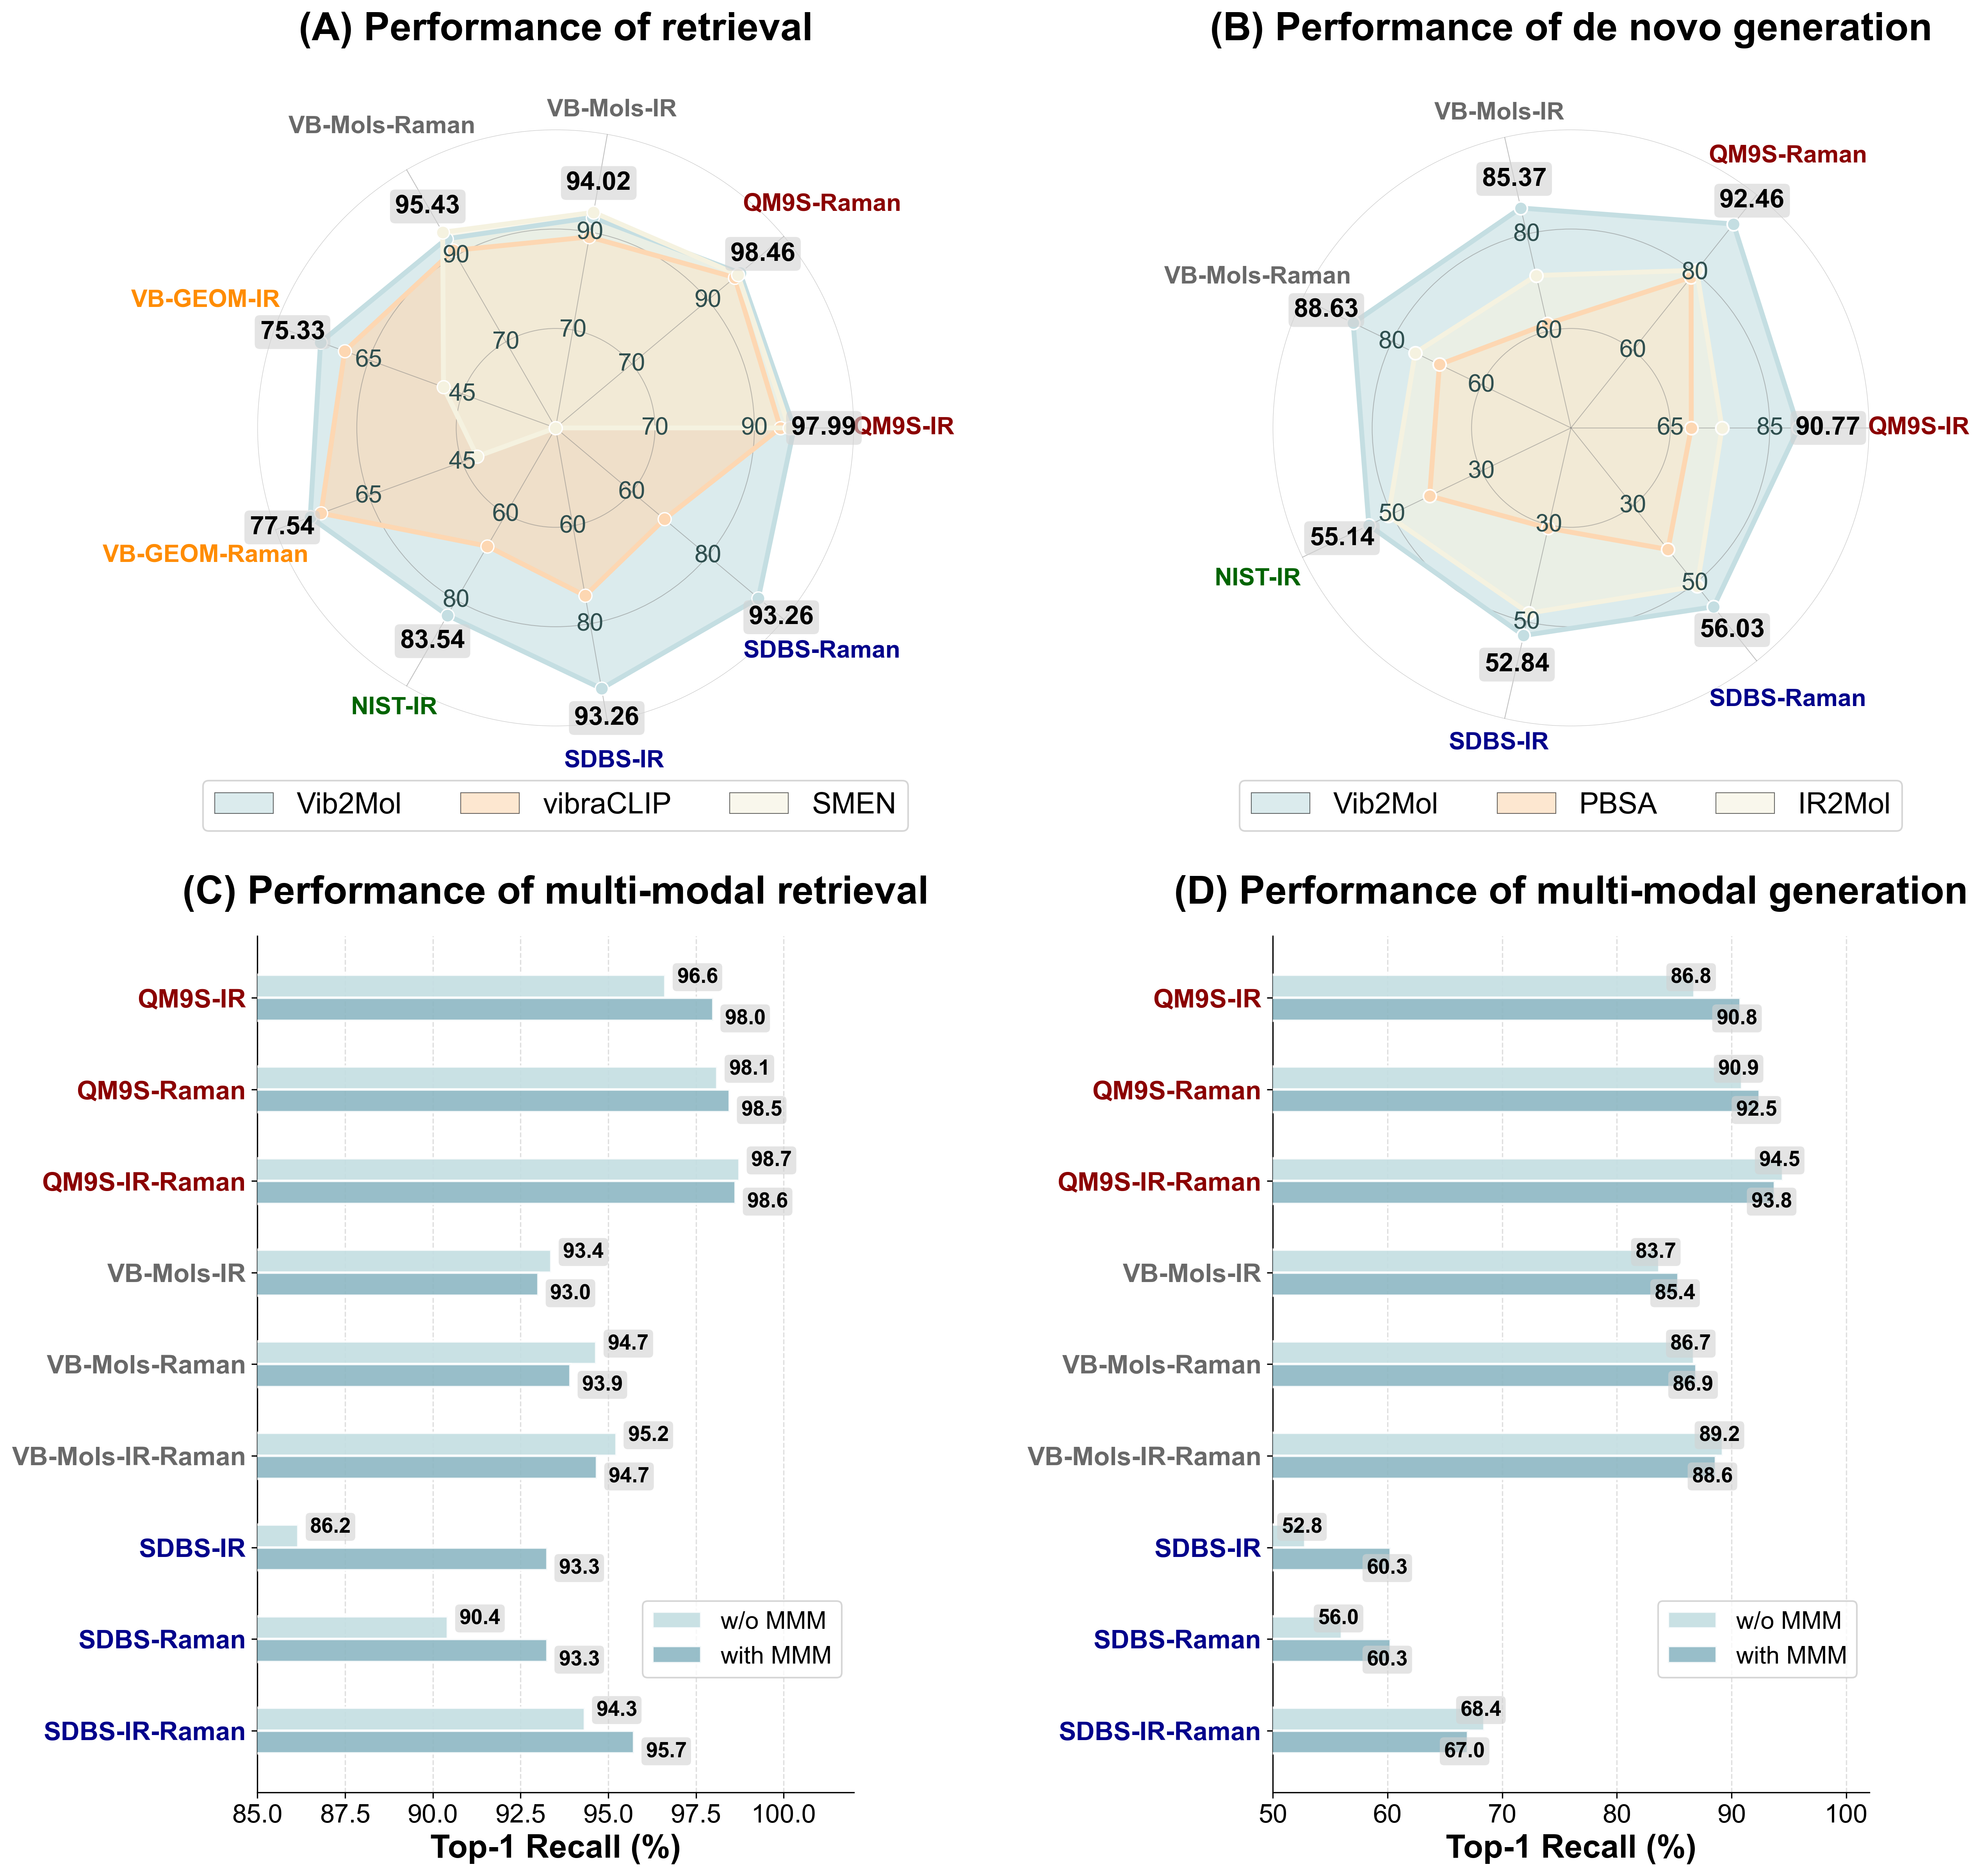

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

# --- Font Setup ---
font_path = './appendix/Arial.ttf'
try:
    matplotlib.font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
except FileNotFoundError:
    print(f"Warning: Font file not found at {font_path}. Using default font.")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Helvetica', 'Liberation Sans', 'DejaVu Sans']


# --- Global Font Sizes ---
fontsize_title = 24
fontsize_label = 20
fontsize_legend = 18
fontsize_ticks = 16
fontsize_data_labels = 12 # Not used in bar charts, but kept for consistency


# --- Data Preparation for Radar Charts ---
# Labels for radar axes (with manual line breaks for better display)
labels_ret = [
    'QM9S-IR',
    'QM9S-Raman',
    'VB-Mols-IR',
    'VB-Mols-Raman',
    'VB-GEOM-IR',
    'VB-GEOM-Raman',
    'NIST-IR',
    'SDBS-IR',
    'SDBS-Raman',
]

labels_gen = [
    'QM9S-IR',
    'QM9S-Raman',
    'VB-Mols-IR',
    'VB-Mols-Raman',
    'NIST-IR',
    'SDBS-IR',
    'SDBS-Raman',
]

# Define colors for each category label (based on original dataset names)
label_colors_map = {
    # 'APIs-Raman': 'lightcoral',
    'QM9S-Raman': 'darkred',
    'QM9S-IR': 'darkred',
    'VB-Mols-Raman': 'dimgray',
    'VB-Mols-IR': 'dimgray',
    'VB-GEOM-IR': 'darkorange',
    'VB-GEOM-Raman': 'darkorange',
    'SDBS-Raman': 'darkblue',
    'SDBS-IR': 'darkblue',
    'NIST-IR': 'darkgreen',
}

# Data for the first radar chart (Generative Models)
values_arr_gen_raw = np.array([
    [90.77, 92.46, 85.37, 88.63, 55.14, 52.84, 56.03, ], # Vib2Mol
    [69.21, 78.77, 61.46, 69.37, 41.56, 30.68, 41.29, ], # PBSA
    [75.39, 80.55, 71.44, 74.79, 50.78, 48.22, 50.71, ], # IR2Mol
    # [51.54, 65.78, 42.25, 53.08, 00.00, 00.00, 00.00, ], # SMEN
])

# Apply transformations for visualization on the first radar chart
values_arr_gen = values_arr_gen_raw.copy()
# gen_offset = np.array([0, 0, 0, 0, 0, 0, 0]).reshape(1, -1)  # Reshape for broadcasting
gen_offset = np.array([-5, 0, 0, 0, 30, 30, 30]).reshape(1, -1)  # Reshape for broadcasting

values_arr_gen += gen_offset  # Apply the offset to all rows
values_arr_gen[values_arr_gen <= 40] = 40 # Set minimum value
label_offset_gen = np.array([0, 0, 5, 0, 0, 5, 0])

# Data for the second radar chart (Retrieval Models)
values_arr_ret_raw = np.array([
    [97.99, 98.46, 93.01, 93.92, 75.33, 77.54, 83.54, 93.26, 93.26, ], # Vib2Mol
    [95.23, 97.07, 89.01, 91.21, 70.16, 75.22, 67.47, 74.28, 68.57, ], # vibraCLIP
    [97.04, 97.89, 94.02, 95.43, 49.01, 41.80, 00.00, 00.00, 00.00, ], # SMEN
])

# Apply transformations for visualization on the second radar chart
values_arr_ret = values_arr_ret_raw.copy()
# ret_offset = np.array([-0, -0, -0, -0, 0, 0, 0, 0, 0]).reshape(1, -1)  # Reshape for broadcasting
ret_offset = np.array([-10, -10, -10, -10, 15, 15, 0, 0, 0]).reshape(1, -1)  # Reshape for broadcasting
values_arr_ret += ret_offset  # Apply the offset to all rows
values_arr_ret[values_arr_ret <= 40] = 40 # Still apply minimum for consistent axis
label_offset_ret = np.array([0, 0, 5, 0, -5, -5, 5, 2, 0])
# --- Common Radar Chart Setup ---

# Calculate angles for radar chart axes
angles_ret = np.linspace(0, 2 * np.pi, len(labels_ret), endpoint=False).tolist()
angles_gen = np.linspace(0, 2 * np.pi, len(labels_gen), endpoint=False).tolist()

angles_for_plot_ret = angles_ret + angles_ret[:1]
angles_for_plot_gen = angles_gen + angles_gen[:1]

def close_values_for_radar(values):
    return values.tolist() + values[:1].tolist()

# Define a consistent color palette for all models across all plots
colors_dict_model = {
    'Vib2Mol': '#C4DEE2',  
    'PBSA': '#fdd7b2',     
    'IR2Mol': '#F5F2E0',   
    'SMEN': '#F5F2E0',     
    'vibraCLIP': "#fdd7b2", 
    'Vib2Mol-MM': "#8db7c3", 
}

# pahs_colors_dict = {
#     'Benzene': '#DD9C84', 
#     'Naphthalene': '#ff7f0e',
#     'Anthracene': '#fdd7b2', 
#     # 'Averaged': '#8db7c3',
# }

# rxn_colors_dict = {'Vib2Mol': '#DD9C84', 'Vib2Mol-RXN': '#8db7c3'}

# --- Figure Creation using GridSpec ---
# Adjusted height and width ratios for more square bottom plots
# Ensure the last row's height and the outer columns' widths are balanced
height_ratios = [1, 1] # Slightly more space for radar titles, thinner spacer, and square bottom
width_ratios = [1, 0.1, 1] # Thinner spacer column
step = 8 # Base unit for scaling the figure
fig = plt.figure(figsize=(step * sum(width_ratios), step * sum(height_ratios)), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(2, 3, height_ratios=height_ratios, width_ratios=width_ratios, figure=fig)


# --- Subplot 1: Retrieval Models Radar Chart (A) ---
polar_ax1 = fig.add_subplot(gs[0, 0], polar=True)
polar_ax1.set_xticklabels(['' for _ in range(len(labels_ret))], fontsize=fontsize_ticks)

polar_ax1.xaxis.grid(False) # Re-enable radial lines
polar_ax1.yaxis.grid(True)
polar_ax1.spines['polar'].set_visible(False)

polar_ax1.xaxis.set_tick_params(width=1.0, color='gray', zorder=0)
polar_ax1.yaxis.set_tick_params(width=0.5, color='lightgray', zorder=0)
polar_ax1.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=0)

model_names_ret = ['Vib2Mol', 'vibraCLIP', 'SMEN']
for i, model_name in enumerate(model_names_ret):
    polar_ax1.plot(angles_for_plot_ret, close_values_for_radar(values_arr_ret[i]),
                   linewidth=3, linestyle='solid', color=colors_dict_model[model_name], zorder=2,
                   marker='o', markersize=8,markerfacecolor=colors_dict_model[model_name], markeredgecolor='white', markeredgewidth=0.8)
    polar_ax1.fill(angles_for_plot_ret, close_values_for_radar(values_arr_ret[i]),
                   color=colors_dict_model[model_name], label=model_name, alpha=0.6, edgecolor='black', linewidth=0.5, zorder=1)

polar_ax1.set_ylim(40, 100)
r_ticks = [40, 60, 80, 100]
polar_ax1.set_rgrids(r_ticks, labels=[], angle=90, fontsize=fontsize_ticks, color='gray')
polar_ax1.tick_params(axis='y', colors='dimgray', labelbottom=False)

polar_ax1.set_xticks(angles_ret)
for i,  angle in enumerate(angles_ret):
    polar_ax1.text(angle, 60, 60-ret_offset[0, i],
                  fontsize=15, ha='center', va='center',
                  color='darkslategray')
for i,  angle in enumerate(angles_ret):
    polar_ax1.text(angle, 80, 80-ret_offset[0, i],
                  fontsize=15, ha='center', va='center',
                  color='darkslategray')
for i,  angle in enumerate(angles_ret):
    polar_ax1.text(angle, 110-label_offset_ret[i], labels_ret[i], 
                  fontsize=15, ha='center', va='center',
                  color=label_colors_map[labels_ret[i]], fontweight='bold')
    
for i, (sota_value, angle) in enumerate(zip(values_arr_ret.max(0), angles_ret)):
    polar_ax1.text(angle, sota_value+6, f'{values_arr_ret_raw.max(0)[i]:.2f}',
                  fontsize=16, ha='center', va='center',
                  color='black', weight='bold',  # Bold black text
                  bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.6)) # Grey background
    

polar_ax1.spines['polar'].set_color('black')
polar_ax1.spines['polar'].set_linewidth(1.5)

polar_ax1.set_title('(A) Performance of retrieval', fontsize=fontsize_title, fontweight='bold', va='bottom', pad=50)
polar_ax1.legend(loc='lower center', fontsize=fontsize_legend, ncol=len(model_names_ret), bbox_to_anchor=(0.5, -0.2))


# --- Subplot 2: Generative Models Radar Chart (B) ---
polar_ax2 = fig.add_subplot(gs[0, 2], polar=True)
polar_ax2.set_xticklabels(['' for _ in range(len(labels_gen))], fontsize=fontsize_ticks)

polar_ax2.xaxis.grid(False)
polar_ax2.yaxis.grid(True)
polar_ax2.spines['polar'].set_visible(False)

polar_ax2.xaxis.set_tick_params(width=1.0, color='gray', zorder=0)
polar_ax2.yaxis.set_tick_params(width=0.5, color='lightgray', zorder=0)
polar_ax2.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=0)

model_names_gen = ['Vib2Mol', 'PBSA', 'IR2Mol', ]
for i, model_name in enumerate(model_names_gen):
    polar_ax2.plot(angles_for_plot_gen, close_values_for_radar(values_arr_gen[i]),
                   linewidth=3, linestyle='solid', color=colors_dict_model[model_name], zorder=2,
                   marker='o', markersize=8, markerfacecolor=colors_dict_model[model_name], markeredgecolor='white', markeredgewidth=1)
    polar_ax2.fill(angles_for_plot_gen, close_values_for_radar(values_arr_gen[i]),
                   color=colors_dict_model[model_name], label=model_name, alpha=0.6, edgecolor='black', linewidth=0.5, zorder=1)

polar_ax2.set_ylim(40, 100)
r_ticks = [40, 60, 80, 100]
polar_ax2.set_rgrids(r_ticks, labels=[], angle=90, fontsize=fontsize_ticks, color='gray')
polar_ax2.tick_params(axis='y', colors='dimgray', labelbottom=False)

polar_ax2.set_xticks(angles_gen)
for i,  angle in enumerate(angles_gen):
    polar_ax2.text(angle, 60, 60-gen_offset[0, i],
                  fontsize=15, ha='center', va='center',
                  color='darkslategray')
for i,  angle in enumerate(angles_gen):
    polar_ax2.text(angle, 80, 80-gen_offset[0, i],
                  fontsize=15, ha='center', va='center',
                  color='darkslategray')
for i,  angle in enumerate(angles_gen):
    polar_ax2.text(angle, 110-label_offset_gen[i], labels_gen[i], 
                  fontsize=15, ha='center', va='center',
                  color=label_colors_map[labels_gen[i]], fontweight='bold')
for i, (sota_value, angle) in enumerate(zip(values_arr_gen.max(0), angles_gen)):
    polar_ax2.text(angle, sota_value+6, f'{values_arr_gen_raw.max(0)[i]:.2f}',
                  fontsize=16, ha='center', va='center',
                  color='black', weight='bold',  # Bold black text
                  bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.6)) # Grey background

polar_ax2.spines['polar'].set_color('black')
polar_ax2.spines['polar'].set_linewidth(1.5)

polar_ax2.set_title('(B) Performance of de novo generation', fontsize=fontsize_title, fontweight='bold', va='bottom', pad=50)
polar_ax2.legend(loc='lower center', fontsize=fontsize_legend, ncol=len(model_names_gen), bbox_to_anchor=(0.5, -0.2))



# --- Data Preparation for Multi-modal Bar Charts ---
labels_mm = [
    'QM9S-IR',
    'QM9S-Raman',
    'QM9S-IR-Raman',
    'VB-Mols-IR',
    'VB-Mols-Raman',
    'VB-Mols-IR-Raman',
    'SDBS-IR',
    'SDBS-Raman',
    'SDBS-IR-Raman',
]

# Define colors for each category label (based on original dataset names)
label_colors_map = {
    'QM9S-IR': 'darkred',
    'QM9S-Raman': 'darkred',
    'QM9S-IR-Raman': 'darkred',
    'VB-Mols-IR': 'dimgray',
    'VB-Mols-Raman': 'dimgray',
    'VB-Mols-IR-Raman': 'dimgray',
    'SDBS-IR': 'darkblue',
    'SDBS-Raman': 'darkblue',
    'SDBS-IR-Raman': 'darkblue',
}

values_arr_mm_ret = np.array([
    [96.63, 98.11, 98.74, 93.38, 94.66, 95.23, 86.17, 90.43, 94.33], # Vib2Mol
    [97.99, 98.46, 98.63, 93.01, 93.92, 94.68, 93.26, 93.26, 95.74], # Vib2Mol-MM
])

values_arr_mm_gen = np.array([
    [86.77, 90.91, 94.49, 83.69, 86.74, 89.24, 52.84, 56.03, 68.44], # Vib2Mol
    [90.77, 92.46, 93.79, 85.37, 86.94, 88.63, 60.28, 60.28, 67.02], # Vib2Mol-MM
])

bar_width = 0.25
alpha_val = 0.8

# --- Subplot 3: Multi-modal Retrieval Bar Chart (C) ---

bar_ax_c = fig.add_subplot(gs[1, 0])
edgecolor_val = 'white' # use white edgecolor to make the bars more clean

num_bars = len(labels_mm)
group_indices = np.arange(num_bars)

# --- 2. plot (barh) ---
for i, model in enumerate(['Vib2Mol', 'Vib2Mol-MM']):
    current_data = values_arr_mm_ret[i][:num_bars]
    
    bars = bar_ax_c.barh(group_indices + i * bar_width, current_data,
                         height=bar_width, label='w/o MMM' if model=='Vib2Mol' else 'with MMM', 
                         color=colors_dict_model[model], 
                         alpha=0.9, edgecolor='white', linewidth=1.5, zorder=3)
    
# label the bars
    for j, val in enumerate(current_data):
        # add offset to the y coordinate to make the label more visible
        v_offset = -0.1 if i == 0 else 0.1
        
        bar_ax_c.text(
            val + 1.5,  
            group_indices[j] + i * bar_width + v_offset, # y coordinate: center position + vertical offset
            f'{val:.1f}',
            ha='right', 
            va='center', 
            fontsize=13, 
            color='black', 
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.6),
            zorder=4
        )

# --- 3. Details beautification (adjusting axes for horizontal bars) ---

# Set Y axis (now the category axis)
bar_ax_c.set_yticks(group_indices + bar_width / 2)
bar_ax_c.set_yticklabels(labels_mm, fontsize=fontsize_label)
bar_ax_c.invert_yaxis()  # Invert Y axis so the first category appears at the top

tick_labels = bar_ax_c.get_yticklabels()

for label in tick_labels:
    dataset_name = label.get_text()
    color = "black"
    for key in label_colors_map:
        if key.startswith(dataset_name):
            color = label_colors_map[key]
            break
            
    label.set_color(color)
    label.set_fontweight('bold') 

    
# set X axis (now the value axis)
bar_ax_c.set_xlabel('Top-1 Recall (%)', fontsize=fontsize_label, fontweight='bold')
bar_ax_c.set_xlim(85, 102) 
bar_ax_c.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

bar_ax_c.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)

for spine in ['top', 'right']:
    bar_ax_c.spines[spine].set_visible(False)

bar_ax_c.legend(fontsize=15, frameon=True, loc='lower right', bbox_to_anchor=(1, 0.12))

# bar_ax_c.set_box_aspect(1)
bar_ax_c.set_title('(C) Performance of multi-modal retrieval', fontsize=fontsize_title, fontweight='bold', pad=20)


# --- Subplot 4: Multi-modal Generative Bar Chart (D) ---
bar_ax_d = fig.add_subplot(gs[1, 2]) # Changed variable name to avoid conflict with bar_ax_c

for i, model in enumerate(['Vib2Mol', 'Vib2Mol-MM']):
    # ensure height data length is 3
    current_data = values_arr_mm_gen[i][:num_bars]
    
    # y axis coordinates: group_indices + offset
    # width parameter corresponds to the value
    bars = bar_ax_d.barh(group_indices + i * bar_width, current_data,
                         height=bar_width, label='w/o MMM' if model=='Vib2Mol' else 'with MMM', 
                         color=colors_dict_model[model], 
                         alpha=0.9, edgecolor='white', linewidth=1.5, zorder=3)
    
# label the bars
    for j, val in enumerate(current_data):
        v_offset = -0.1 if i == 0 else 0.1
        
        bar_ax_d.text(
            val + 1.5,  
            group_indices[j] + i * bar_width + v_offset, 
            f'{val:.1f}',
            ha='right', 
            va='center', 
            fontsize=13, 
            color='black', 
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.6),
            zorder=4
        )

bar_ax_d.set_yticks(group_indices + bar_width / 2)
bar_ax_d.set_yticklabels(labels_mm, fontsize=fontsize_label)
bar_ax_d.invert_yaxis()  

tick_labels = bar_ax_d.get_yticklabels()

for label in tick_labels:
    dataset_name = label.get_text()
    color = "black"
    for key in label_colors_map:
        if key.startswith(dataset_name):
            color = label_colors_map[key]
            break
            
    label.set_color(color)
    label.set_fontweight('bold') 

    
bar_ax_d.set_xlabel('Top-1 Recall (%)', fontsize=fontsize_label, fontweight='bold')
bar_ax_d.set_xlim(50, 102) 
bar_ax_d.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

bar_ax_d.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)

for spine in ['top', 'right']:
    bar_ax_d.spines[spine].set_visible(False)

bar_ax_d.legend(fontsize=15, frameon=True, loc='lower right', bbox_to_anchor=(1, 0.12))

# bar_ax_d.set_box_aspect(1)
bar_ax_d.set_title('(D) Performance of multi-modal generation', fontsize=fontsize_title, fontweight='bold', pad=20)

# Save the figure as svg
plt.savefig('figure3.svg', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4 Ablation Study and visualization

In [2]:
import numpy as np
ret = np.load('appendix/ret_embeds.npz')
all_spectra_embeddings = ret['all_spectra_embeddings']
all_smiles_embeddings = ret['all_smiles_embeddings']
all_spectra_embeddings_trained = ret['all_spectra_embeddings_trained']
all_smiles_embeddings_trained = ret['all_smiles_embeddings_trained']


In [3]:
from tqdm import tqdm

sim_list = []

for smiles_embeds, spec_embeds in tqdm(zip(all_smiles_embeddings, all_spectra_embeddings), total=len(all_smiles_embeddings)):
    sim = np.dot(smiles_embeds.reshape(1, -1), spec_embeds.reshape(-1, 1)) / (
        np.linalg.norm(smiles_embeds) * np.linalg.norm(spec_embeds))
    sim_list.append(sim)

sim_list = np.array(sim_list).squeeze()
sim_list.std(), sim_list.mean()

100%|██████████| 37570/37570 [00:00<00:00, 285749.52it/s]


(0.0051874435, -0.023396352)

In [4]:
sim_list_trained = []

for smiles_embeds, spec_embeds in tqdm(zip(all_smiles_embeddings_trained, all_spectra_embeddings_trained), total=len(all_smiles_embeddings_trained)):
    sim = np.dot(smiles_embeds.reshape(1, -1), spec_embeds.reshape(-1, 1)) / (
        np.linalg.norm(smiles_embeds) * np.linalg.norm(spec_embeds))
    sim_list_trained.append(sim)

sim_list_trained = np.array(sim_list_trained).squeeze()
sim_list_trained.std(), sim_list_trained.mean()

100%|██████████| 37570/37570 [00:00<00:00, 282402.45it/s]


(0.04715258, 0.86480194)

In [5]:
import pandas as pd
import numpy as np

df_formula = pd.read_csv('appendix/formula_rerank.csv')
from rdkit import Chem

fg_dict = {
'hydroxyl':'[#6][OX2H]', 
'ketone carbonyl':'[#6][CX3](=O)[#6]', 
'aldehydes carbonyl':'[CX3H1](=O)[#6,H]', 
'carboxyl':'[CX3](=O)[OX2H]', 
'ester':'[#6][CX3](=O)[OX2H0][#6]', 
'amine':'[NX3;H2,H1,H0;!$(NC=O)]', 
'amide':'[NX3][CX3](=[OX1])[#6]', 
'ether':'[OD2]([#6])[#6]', 
'alkene':'[CX3]=[CX3]', 
'aromatic ring':'[$([cX3](:*):*),$([cX2+](:*):*)]', 
'alkyl halide':'[#6][F,Cl,Br,I]', 
'nitrile':'[NX1]#[CX2]', 
'thiol':'[#16X2H]',
'sulfide':'[#16X2H0]',
'alkyne':'[CX2]#[CX2]',
}

def classify_smiles(smiles):
    """
    classify a SMILES string into different functional groups.
    """
    mol = Chem.MolFromSmiles(smiles)
    correct = np.zeros(len(fg_dict), dtype=np.float32)

    for i, (fg, smarts) in enumerate(fg_dict.items()):
        pattern = Chem.MolFromSmarts(smarts)
        if mol and mol.HasSubstructMatch(pattern):
            correct[i] = 1.0
        else:
            correct[i] = 0.0
    return correct

def classify_smiles_list(smiles_list):
    """
    classify a list of SMILES strings into different functional groups.
    """
    classifications = []
    for smiles in smiles_list:
        classifications.append(classify_smiles(smiles))
    return classifications

df_formula['tgt_fg'] = classify_smiles_list(df_formula['tgt'])
df_formula['pred_fg'] = classify_smiles_list(df_formula['pred'])

for fg in fg_dict.keys():
    df_formula[fg] = df_formula['tgt_fg'].apply(lambda x: x[list(fg_dict.keys()).index(fg)])


In [6]:
# evaluate the classification with F1 score of each functional group
from sklearn.metrics import f1_score

def evaluate_classification(df, fg_dict):
    """
    evaluate the classification results with F1 score of each functional group.
    """
    f1_scores = {}
    for fg in fg_dict.keys():
        y_true = df['tgt_fg'].apply(lambda x: x[list(fg_dict.keys()).index(fg)])
        y_pred = df['pred_fg'].apply(lambda x: x[list(fg_dict.keys()).index(fg)])
        f1_scores[fg] = f1_score(y_true, y_pred, zero_division=0)
    return f1_scores

def get_num_of_each_fg(df, fg_dict):
    """
    calculate the number of samples for each functional group.
    """
    num_of_each_fg = {}
    for fg in fg_dict.keys():
        num_of_each_fg[fg] = df['tgt_fg'].apply(lambda x: x[list(fg_dict.keys()).index(fg)]).sum()
    return num_of_each_fg


num_of_each_fg = get_num_of_each_fg(df_formula, fg_dict)
f1_scores_formula = evaluate_classification(df_formula, fg_dict)


In [7]:
import matplotlib.pyplot as plt
import operator

ret_recalls = {
'hydroxyl':0.89425, 
'ketone':0.93347, 
'aldehydes':0.94238, 
'carboxyl':0.76884, 
'ester':0.91893, 
'amine':0.90119, 
'amide':0.91399, 
'ether':0.90911,
'alkene':0.88794, 
'aromatic ring':0.88878, 
'alkyl halide':0.88547, 
'nitrile':0.95768, 
'thiol':0.93103,
'sulfide':0.89901,
'alkyne':0.96529,
}

f1_scores_formula = {
    'hydroxyl': 0.9839825263924281,
    'ketone': 0.9701247951594605,
    'aldehydes': 0.9926459985580389,
    'carboxyl': 0.8835555555555555,
    'ester': 0.9657130377811749,
    'amine': 0.9752158894645941,
    'amide': 0.948634427461789,
    'ether': 0.9876940242181603,
    'alkene': 0.9745853716740246,
    'aromatic ring': 0.9769398952188441,
    'alkyl halide': 0.9830755232029117,
    'nitrile': 0.995868357315857,
    'thiol': 0.6730769230769231,
    'sulfide': 0.9343192692474989,
    'alkyne': 0.9993056519927788
    }

num_of_each_fg ={
    'hydroxyl': 11092.0,
    'ketone': 3998.0,
    'aldehydes': 3471.0,
    'carboxyl': 584.0,
    'ester': 2319.0,
    'amine': 11729.0,
    'amide': 4081.0,
    'ether': 15359.0,
    'alkene': 4230.0,
    'aromatic ring': 12381.0,
    'alkyl halide': 2794.0,
    'nitrile': 3521.0,
    'thiol': 58.0,
    'sulfide': 1218.0,
    'alkyne': 3601.0}


gen_acc = {
    'hydroxyl': 0.870176703930761,
    'ketone': 0.8806903451725863,
    'aldehydes': 0.9144338807260155,
    'carboxyl': 0.7722602739726028,
    'ester': 0.8460543337645536,
    'amine': 0.8325517946969051,
    'amide': 0.8186718941435922,
    'ether': 0.8643140829481086,
    'alkene': 0.8144208037825059,
    'aromatic ring': 0.8118084161214765,
    'alkyl halide': 0.7949176807444523,
    'nitrile': 0.926725362113036,
    'thiol': 0.5862068965517241,
    'sulfide': 0.6789819376026273,
    'alkyne': 0.9616773118578172
    }

# sort the functional groups by the number of samples in descending order
sorted_items = sorted(num_of_each_fg.items(), key=operator.itemgetter(1), reverse=True)
sorted_fgs = [item[0] for item in sorted_items]
sorted_num_of_each_fg_values = [item[1] for item in sorted_items]

sorted_ret_recalls_values = [ret_recalls[fg] for fg in sorted_fgs]
sorted_f1_scores_values_formula = [f1_scores_formula[fg] for fg in sorted_fgs]
sorted_gen_acc_values = [gen_acc[fg] for fg in sorted_fgs]


In [8]:
# weighted-averaged f1
avg_f1 = np.array(list(f1_scores_formula.values())) * np.array(list(num_of_each_fg.values()))
avg_f1 = avg_f1.sum() / np.array(list(num_of_each_fg.values())).sum()
avg_f1

0.9786690360652742

In [9]:
# weighted-averaged recall
avg_recall = np.array(list(ret_recalls.values())) * np.array(list(num_of_each_fg.values()))
avg_recall = avg_recall.sum() / np.array(list(num_of_each_fg.values())).sum()
avg_recall

0.9075050538316177

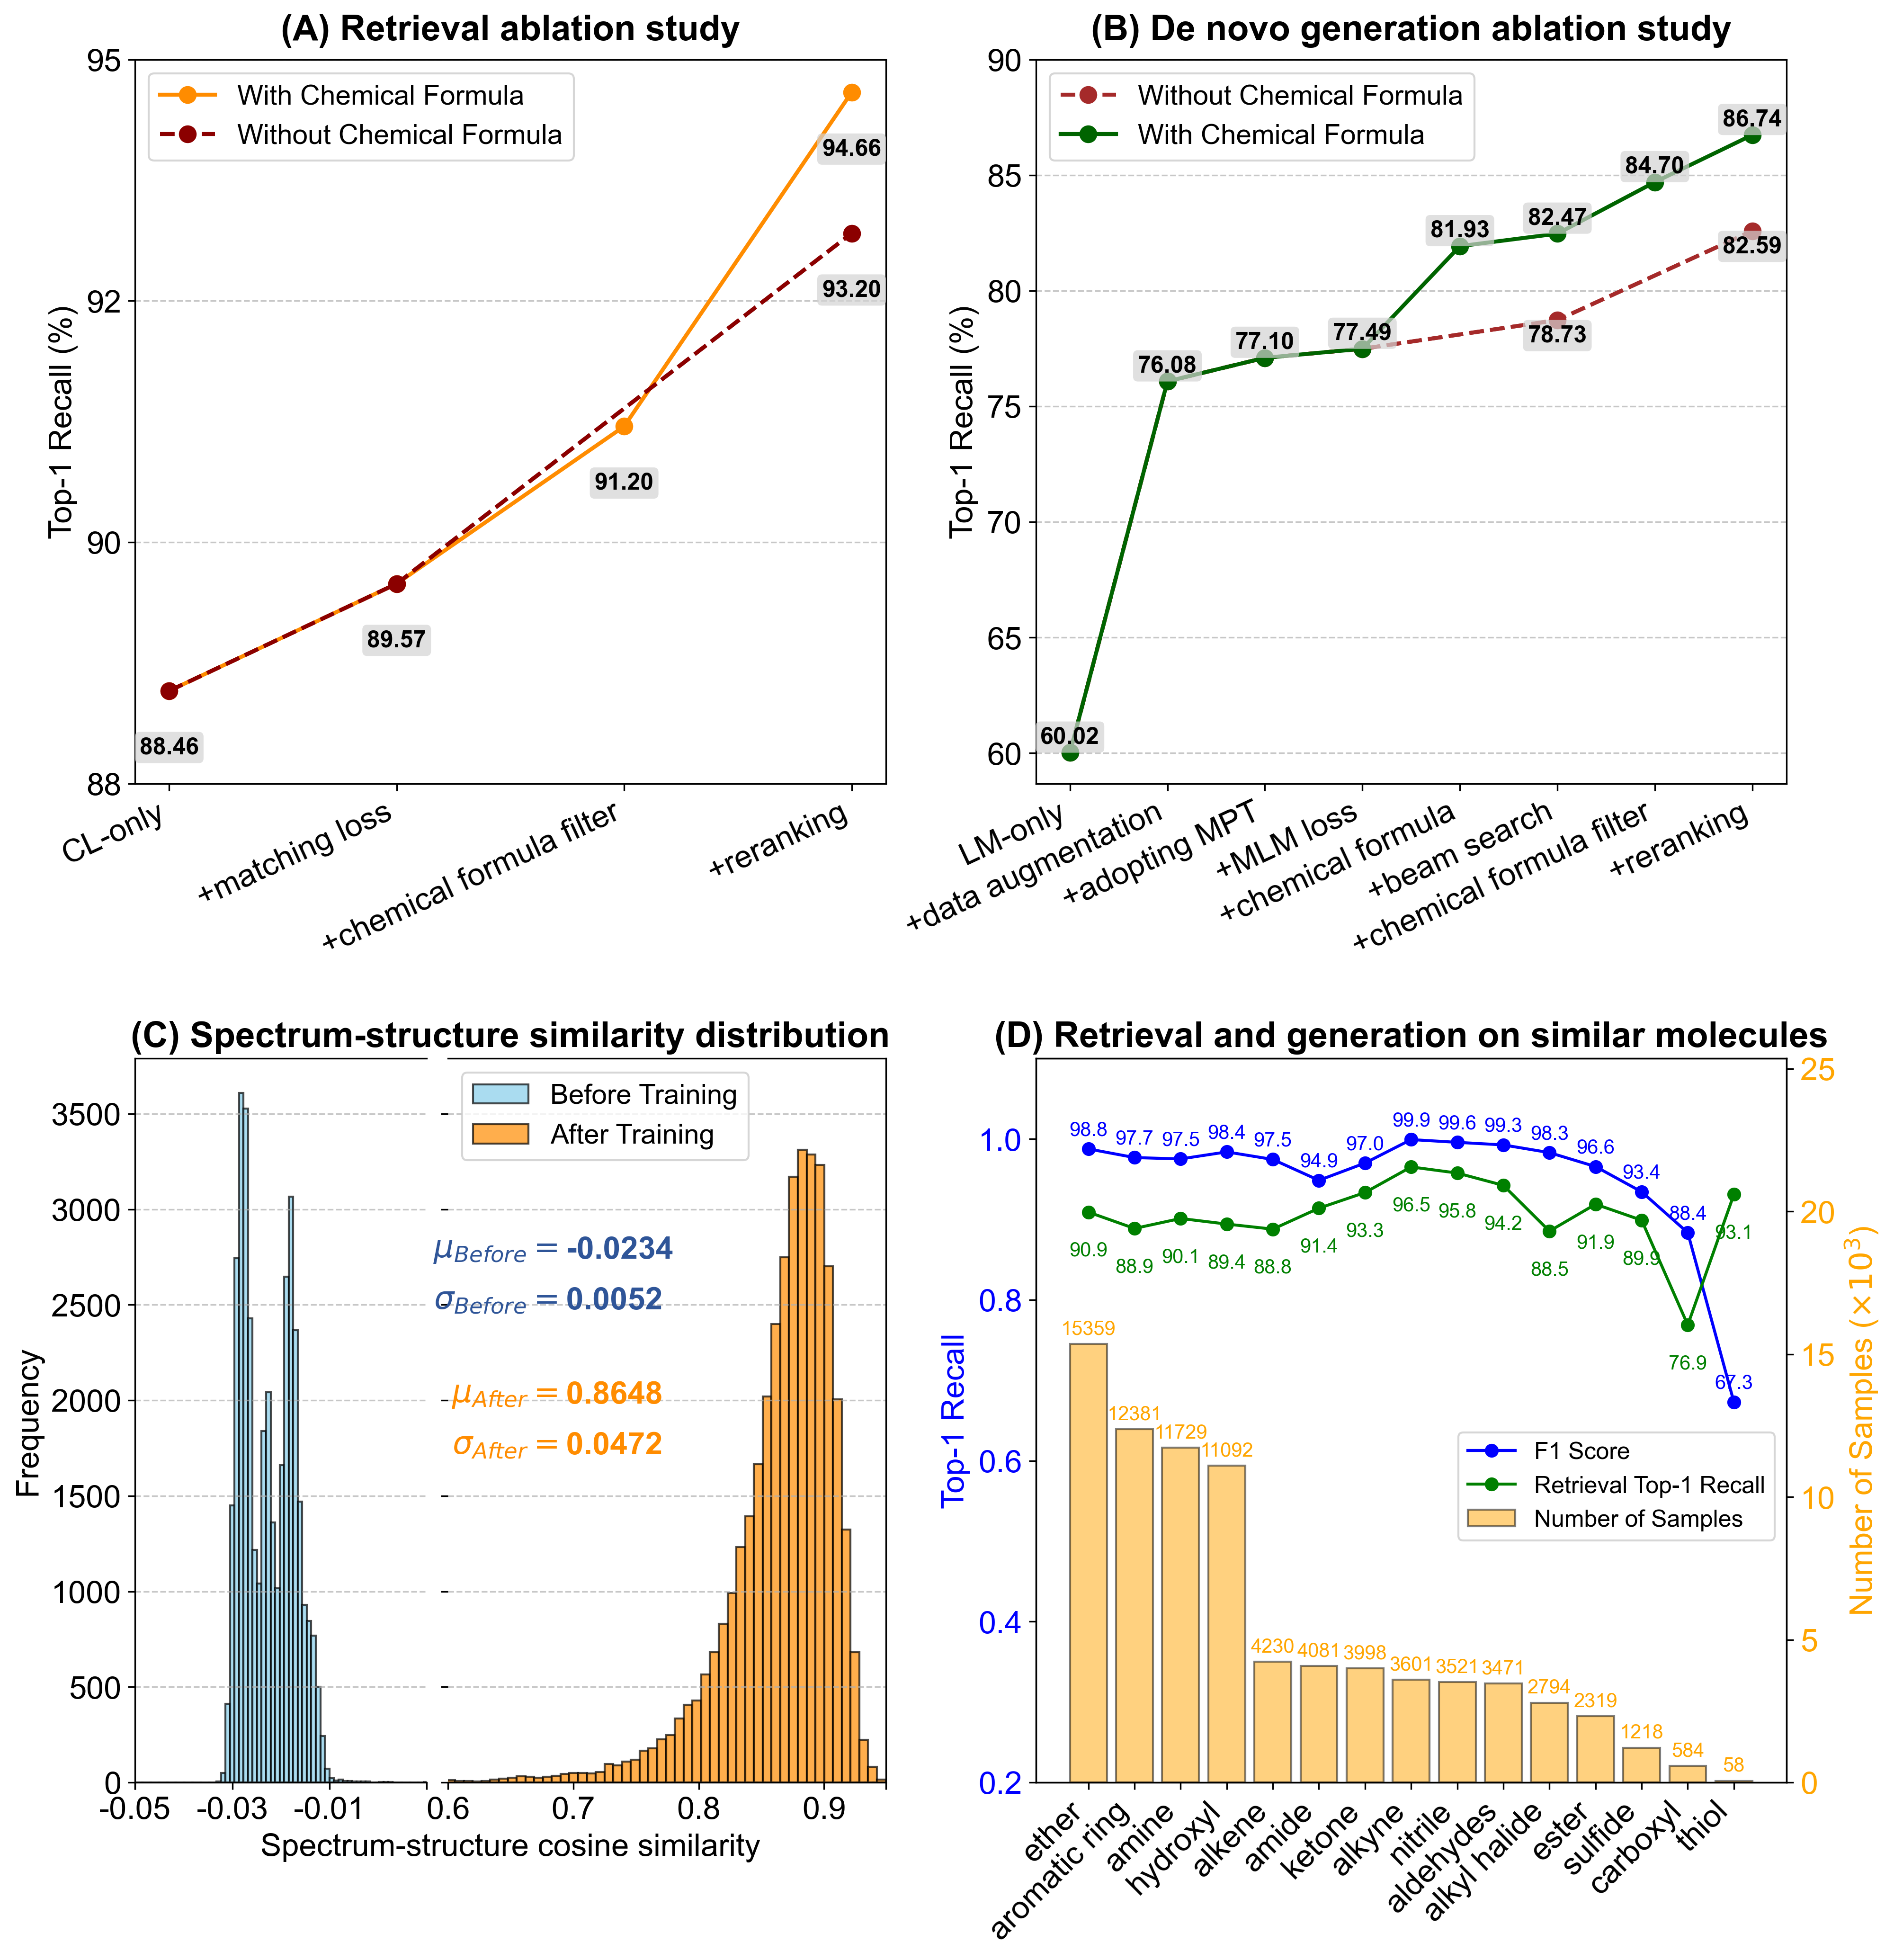

In [10]:
# retrieval ablation study
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

# --- Font Setup ---
font_path = './appendix/Arial.ttf'
try:
    matplotlib.font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
except FileNotFoundError:
    print("Font file not found. Please check the path.")

# --- Global Font Sizes ---
fontsize_title = 18
fontsize_label = 16
fontsize_legend = 14
fontsize_ticks = 16
fontsize_data_labels = 12 # Not used in bar charts, but kept for consistency


height_ratios = [1, 0.1, 1] # Slightly more space for radar titles, thinner spacer, and square bottom
width_ratios = [1, 1] # Thinner spacer column
step = 7.5 # Base unit for scaling the figure
fig = plt.figure(figsize=(step * sum(width_ratios), step * sum(height_ratios)), dpi=300)
gs = gridspec.GridSpec(3, 2, height_ratios=height_ratios, width_ratios=width_ratios, figure=fig)

# --- Subplot 1 (Top-Left) ---
ax1 = fig.add_subplot(gs[0, 0])
# --- Data Preparation for Line Charts ---
ret_ablation_labels = [
    'CL-only',
    '+matching loss',
    '+chemical formula filter',
    '+reranking',
]
# Data for the ablation study
ret_ablation_values = np.array([88.46, 89.57, 91.20, 94.66])
ret_ablation_labels_comp = np.array([88.46, 89.57, np.nan, 93.20])  # Using np.nan for missing points

# --- Interpolate NaN values for the 'comp' line ---
interpolated_values_comp = ret_ablation_labels_comp.copy()

# Find indices and values of non-NaN points
valid_indices = np.where(~np.isnan(interpolated_values_comp))[0]
valid_values = interpolated_values_comp[valid_indices]

interpolated_values_comp = np.interp(np.arange(len(ret_ablation_labels)),
                                    valid_indices,
                                    valid_values)
ax1.plot(ret_ablation_labels, ret_ablation_values, marker='o', linestyle='-', color='darkorange', linewidth=2, markersize=8, label='With Chemical Formula')

ax1.plot(ret_ablation_labels, interpolated_values_comp, marker='None', linestyle='--', 
         color='darkred', linewidth=2) # No marker on the interpolated line

ax1.plot(np.array(ret_ablation_labels)[~np.isnan(ret_ablation_labels_comp)],
         ret_ablation_labels_comp[~np.isnan(ret_ablation_labels_comp)],
         marker='o', linestyle='--', color='darkred', linewidth=2, markersize=8, label='Without Chemical Formula') # No line, just markers


ax1.set_xticks(range(len(ret_ablation_labels)))
ax1.set_xticklabels(ret_ablation_labels, rotation=25, ha='right', fontsize=fontsize_ticks)

min_val = np.floor(np.min(ret_ablation_values) / 2.5) * 2.5
max_val = np.ceil(np.max(ret_ablation_values) / 2.5) * 2.5
ax1.set_yticks(np.arange(min_val, max_val + 2.5, 2.5))
ax1.set_yticklabels([f'{y:.0f}' for y in ax1.get_yticks()], fontsize=fontsize_ticks)

ax1.set_ylabel('Top-1 Recall (%)', fontsize=fontsize_label)
ax1.set_title('(A) Retrieval ablation study', fontsize=fontsize_title, fontweight='bold', pad=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(ret_ablation_values):
    ax1.text(i, value - 0.7, f'{value:.2f}', ha='center', va='bottom', fontsize=fontsize_data_labels, color='black', weight='bold',  # Bold black text
                  bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.7)) # Grey background

# Add data labels for the second line (ONLY for original non-interpolated values)
for i, value in enumerate(ret_ablation_labels_comp):
    if not np.isnan(value) and i >= 2: # Only label actual data points
        ax1.text(i, value - 0.7, f'{value:.2f}', ha='center', va='bottom', fontsize=fontsize_data_labels,
                 color='black', weight='bold',  # Bold black text
                  bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.7)) # Grey background

ax1.legend(fontsize=fontsize_legend, loc='upper left', frameon=True) # Position legend


# --- Subplot 3 (Bottom, Spanning Two Columns) ---
ax2 = fig.add_subplot(gs[0, -1]) # This makes it span all columns in the second row

# --- Data Preparation for Line Chart ---
lm_ablation_labels = [
    'LM-only',
    '+data augmentation',
    '+adopting MPT',
    '+MLM loss',
    '+chemical formula',
    '+beam search',
    '+chemical formula filter',
    '+reranking',
]

lm_ablation_values = np.array([60.02, 76.08, 77.10, 77.49, 81.93, 82.47, 84.70, 86.74])
lm_ablation_values_comp = np.array([60.02, 76.08, 77.10, 77.49, np.nan, 78.73, np.nan, 82.59])

# --- Interpolate NaN values for the 'comp' line ---
interpolated_values_comp = lm_ablation_values_comp.copy()

# Find indices and values of non-NaN points
valid_indices = np.where(~np.isnan(interpolated_values_comp))[0]
valid_values = interpolated_values_comp[valid_indices]

interpolated_values_comp = np.interp(np.arange(len(lm_ablation_labels)),
                                    valid_indices,
                                    valid_values)


# --- Plotting ---
ax2.plot(lm_ablation_labels, interpolated_values_comp, marker='None', linestyle='--', 
         color='brown', linewidth=2) # No marker on the interpolated line

ax2.plot(np.array(lm_ablation_labels)[~np.isnan(lm_ablation_values_comp)],
         lm_ablation_values_comp[~np.isnan(lm_ablation_values_comp)],
         marker='o', linestyle='--', color='brown', linewidth=2, markersize=8, label='Without Chemical Formula') # No line, just markers

ax2.plot(lm_ablation_labels, lm_ablation_values, marker='o', linestyle='-',
         color='darkgreen', linewidth=2, markersize=8, label='With Chemical Formula')

ax2.set_xticks(range(len(lm_ablation_labels)))
ax2.set_xticklabels(lm_ablation_labels, rotation=25, ha='right', fontsize=fontsize_ticks)

# Adjust y-axis limits to accommodate both lines
all_valid_values = np.concatenate([lm_ablation_values[~np.isnan(lm_ablation_values)],
                                   lm_ablation_values_comp[~np.isnan(lm_ablation_values_comp)]]) # Use original comp values for range
min_val = np.floor(np.min(all_valid_values) / 5) * 5
max_val = np.ceil(np.max(all_valid_values) / 5) * 5

ax2.set_yticks(np.arange(min_val, max_val + 5, 5))
ax2.set_yticklabels([f'{y:.0f}' for y in ax2.get_yticks()], fontsize=fontsize_ticks)
ax2.set_ylabel('Top-1 Recall (%)', fontsize=fontsize_label)
ax2.set_title('(B) De novo generation ablation study', fontsize=fontsize_title, fontweight='bold', pad=10)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels for the first line (with chemical formula)
for i, value in enumerate(lm_ablation_values):
    ax2.text(i, value + 0.2, f'{value:.2f}', ha='center', va='bottom', fontsize=fontsize_data_labels,
             color='black', weight='bold',  # Bold black text
                  bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.7)) # Grey background

# Add data labels for the second line (ONLY for original non-interpolated values)
for i, value in enumerate(lm_ablation_values_comp):
    if not np.isnan(value) and i >= 4: # Only label actual data points
        ax2.text(i, value - 0.2, f'{value:.2f}', ha='center', va='top', fontsize=fontsize_data_labels,
                 color='black', weight='bold',  # Bold black text
                  bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.7)) # Grey background

ax2.legend(fontsize=fontsize_legend)



# --- Plotting Configuration ---
# Histogram break point settings (adjusted for your new simulated data range)
hist_bins = 100
hist_break_point_low = 0.005  # Upper limit of the lower X-axis segment
hist_break_point_high = 0.6 # Lower limit of the upper X-axis segment

# --- Create 2x2 Master Figure Layout ---

# --- Top-Left Plot: Broken X-axis Histogram ---
# Calculate histogram data
counts_before, bin_edges_before = np.histogram(sim_list, bins=hist_bins)
counts_after, bin_edges_after = np.histogram(sim_list_trained, bins=hist_bins)

# Get the bounding box of the top-left GridSpec cell
ax_hist = fig.add_subplot(gs[-1, 0])
# hide the top and right spines
ax_hist.spines['top'].set_visible(False)
ax_hist.spines['right'].set_visible(False)
# hide the bottom spine
ax_hist.spines['bottom'].set_visible(False)
# hide the left spine
ax_hist.spines['left'].set_visible(False)
# hide the y-ticks
ax_hist.set_yticks([])
# place the placeholder text
ax_hist.set_xticks([0, 1])
ax_hist.set_xticklabels(['', ' '], fontsize=fontsize_ticks)

bbox_hist = gs[-1, 0].get_position(fig).bounds

# Calculate dynamic widths for the left and right segments of the broken axis
# based on their data ranges. This makes the segments' widths more representative.
min_overall_hist = min(np.min(sim_list), np.min(sim_list_trained))
max_overall_hist = max(np.max(sim_list), np.max(sim_list_trained))
total_hist_data_range = max_overall_hist - min_overall_hist

left_segment_data_ratio = 0.4
right_segment_data_ratio = 0.6

# Normalize segment ratios to sum up to 1 if we only consider the data-containing parts
normalized_total_data_ratio = left_segment_data_ratio + right_segment_data_ratio

left_segment_ratio = left_segment_data_ratio / normalized_total_data_ratio
right_segment_ratio = right_segment_data_ratio / normalized_total_data_ratio

# Define the visual gap width for the break
break_gap_width_ratio = 0.01 # Adjust this to control the visual gap size

# Calculate the actual widths for the axes within the GridSpec cell's bounding box
available_width_for_axes = bbox_hist[2] - break_gap_width_ratio
left_axis_width = available_width_for_axes * left_segment_ratio
right_axis_width = available_width_for_axes * right_segment_ratio

# Create the left and right histogram axes using `fig.add_axes` for precise positioning
ax_hist_left = fig.add_axes([bbox_hist[0], bbox_hist[1], left_axis_width, bbox_hist[3]])
ax_hist_right = fig.add_axes([bbox_hist[0] + left_axis_width + break_gap_width_ratio, bbox_hist[1], right_axis_width, bbox_hist[3]], sharey=ax_hist_left)

# Plot data on the left histogram axis
ax_hist_left.bar(bin_edges_before[:-1], counts_before, width=np.diff(bin_edges_before), edgecolor='black', alpha=0.7, color='skyblue', label='Before Training', align='edge')
ax_hist_left.set_xlim(min_overall_hist, hist_break_point_low)
# make x-ticks more sparse for better readability
hist_break_point_low = min(hist_break_point_low, max_overall_hist)  # Ensure break point is within the overall range
ax_hist_left.set_xticks(np.linspace(min_overall_hist, hist_break_point_low, 4))
ax_hist_left.set_xticklabels([f'{x:.2f}' for x in np.linspace(min_overall_hist, hist_break_point_low, 4)][:-1]+[''], fontsize=fontsize_ticks)
ax_hist_left.tick_params(axis='y', labelsize=fontsize_ticks)
ax_hist_left.set_ylabel("Frequency", fontsize=fontsize_label)
ax_hist_left.grid(axis='y', linestyle='--', alpha=0.7)

# Plot data on the right histogram axis
ax_hist_right.bar(bin_edges_after[:-1], counts_after, width=np.diff(bin_edges_after), edgecolor='black', alpha=0.7, color='darkorange', align='edge', label='After Training')
ax_hist_right.set_xlim(hist_break_point_high, max_overall_hist)
ax_hist_right.tick_params(axis='x', labelsize=fontsize_ticks)
ax_hist_right.tick_params(labelleft=False)
ax_hist_right.grid(axis='y', linestyle='--', alpha=0.7)

# Hide spines between the two histogram axes
ax_hist_left.spines['right'].set_visible(False)
ax_hist_right.spines['left'].set_visible(False)

# 整合 ax_hist_left 和 ax_hist_right 的图例
handles_hist, labels_hist = ax_hist_left.get_legend_handles_labels()
handles_hist2, labels_hist2 = ax_hist_right.get_legend_handles_labels()
# merge legends
ax_hist_right.legend(handles_hist + handles_hist2, labels_hist + labels_hist2, loc='upper left', fontsize=fontsize_legend, ) # 调整位置以避免覆盖
# add title
ax_hist.set_title('(C) Spectrum-structure similarity distribution',
             fontsize=fontsize_title, fontweight='bold') # Adjust y for vertical position

# # Set the overall figure xlabel
ax_hist.set_xlabel('Spectrum-structure cosine similarity', fontsize=fontsize_label, y=bbox_hist[1] - 0.05) # Adjust y to position it below the broken axis

# Display mean and std as text on the plot (more effective than print)
mean_before = np.mean(sim_list)
std_before = np.std(sim_list)
mean_after = np.mean(sim_list_trained)
std_after = np.std(sim_list_trained)

base_params = {
    'transform': ax_hist_right.transAxes,
    'fontsize': 16,
    'fontweight': 'bold',
    'linespacing': 2.0,
    'verticalalignment': 'center'
}

y_center = 0.6
y_offset = 0.1  

# 3. plot Before group
ax_hist_right.text(0.25, y_center + y_offset, 
                   f"$\\mu_{{Before}} =$\n$\\sigma_{{Before}} =$", 
                   color='#2f5598', horizontalalignment='right', **base_params)
ax_hist_right.text(0.25, y_center + y_offset, 
                   f" {mean_before:.4f}\n {std_before:.4f}", 
                   color='#2f5598', horizontalalignment='left', **base_params)

# 4. plot After group
ax_hist_right.text(0.25, y_center - y_offset, 
                   f"$\\mu_{{After}} =$\n$\\sigma_{{After}} =$", 
                   color='darkorange', horizontalalignment='right', **base_params)
ax_hist_right.text(0.25, y_center - y_offset, 
                   f" {mean_after:.4f}\n {std_after:.4f}", 
                   color='darkorange', horizontalalignment='left', **base_params)


# --- right subplot: F1 Score and Retrieval Recall ---
ax_fg = fig.add_subplot(gs[-1, -1])

# plot F1 Score and Retrieval Recall
line_f1, = ax_fg.plot(sorted_fgs, sorted_f1_scores_values_formula, marker='o', linestyle='-', color='blue', label='F1 Score')
line_recall, = ax_fg.plot(sorted_fgs, sorted_ret_recalls_values, marker='o', linestyle='-', color='green', label='Retrieval Top-1 Recall')
# ax_fg.set_xlabel('Functional Groups', fontsize=fontsize_label)
ax_fg.set_ylabel('Top-1 Recall', color='blue', fontsize=fontsize_label)
ax_fg.tick_params(axis='y', labelcolor='blue', labelsize=fontsize_ticks)
ax_fg.set_ylim(0.2, 1.1)
ax_fg.tick_params(axis='x', rotation=45, labelsize=12) 
plt.setp(ax_fg.get_xticklabels(), ha='right', fontsize=fontsize_ticks) 
ax_fg.set_title("(D) Retrieval and generation on similar molecules", fontsize=fontsize_title, fontweight='bold')

# label data points
for i, fg in enumerate(sorted_fgs):
    ax_fg.annotate(f'{sorted_f1_scores_values_formula[i]*100:.1f}',
                   xy=(fg, sorted_f1_scores_values_formula[i]),
                   xytext=(0, 5), textcoords='offset points', ha='center', va='bottom',
                   fontsize=10, color='blue')
    ax_fg.annotate(f'{sorted_ret_recalls_values[i]*100:.1f}',
                   xy=(fg, sorted_ret_recalls_values[i]),
                   xytext=(0, -15), textcoords='offset points', ha='center', va='top',
                   fontsize=10, color='green')


# create a second y-axis to plot the number of samples
ax_fg2 = ax_fg.twinx()
bars_samples = ax_fg2.bar(sorted_fgs, sorted_num_of_each_fg_values, edgecolor='black', alpha=0.5, color='orange', label='Number of Samples')
ax_fg2.set_ylabel('Number of Samples ($\\times 10^3$)', color='orange', fontsize=fontsize_label)
ax_fg2.set_yticks(np.arange(0, max(sorted_num_of_each_fg_values) + 10000, 5000))
ax_fg2.set_yticklabels([f'{int(tick/1000)}' for tick in ax_fg2.get_yticks()])
ax_fg2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize_ticks)
ax_fg2.set_ylim(0, max(sorted_num_of_each_fg_values) + 10000) # 设置 y 轴范围

# merge legends
handles_fg, labels_fg = ax_fg.get_legend_handles_labels()
handles_fg2, labels_fg2 = ax_fg2.get_legend_handles_labels()
# 合并图例
ax_fg.legend(handles_fg + handles_fg2, labels_fg + labels_fg2, loc='upper right', fontsize=12, bbox_to_anchor=(1, 0.5)) # 调整位置以避免覆盖
# ax_fg.set_box_aspect(1)


# label data points on the second y-axis
for bar in bars_samples:
    height = bar.get_height()
    ax_fg2.annotate(f'{height:.0f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3), # 3 points vertical offset
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=10, color='orange')

# fig.tight_layout() 
plt.savefig('figure4.svg')


# Figure S1 visualize embedding space

In [ ]:
from rdkit import Chem
from rdkit.Chem import DataStructs
def taminoto_similarity(smiles1, smiles2):
    try:
        mol1 = Chem.MolFromSmiles(smiles1)
        mol2 = Chem.MolFromSmiles(smiles2)
        fp1 = Chem.RDKFingerprint(mol1, fpSize=2048)
        fp2 = Chem.RDKFingerprint(mol2, fpSize=2048)
        return DataStructs.TanimotoSimilarity(fp1, fp2)
    except:
        return 0

df_formula['tanimoto'] = df_formula.apply(lambda x: taminoto_similarity(x['pred'], x['tgt']), axis=1)
selected_df_gen = df_formula[df_formula.pred != '*']
selected_df_gen['tanimoto'].mean(), selected_df_gen[selected_df_gen.correct != 1]['tanimoto'].mean(), selected_df_gen[selected_df_gen.correct == 1]['tanimoto'].mean()

In [ ]:
selected_df_gen[selected_df_gen.correct != 1]['tanimoto'].quantile(0.25), selected_df_gen[selected_df_gen.correct != 1]['tanimoto'].quantile(0.44)

(0.35672415668548085, 0.5036496350364964)

In [ ]:
df_ret = pd.read_csv('SI/df_ret.csv')
df_ret['tanimoto'] = df_ret.apply(lambda x: taminoto_similarity(x['top1_smiles'], x['tgt']), axis=1)
df_ret['tanimoto'].mean(), df_ret[df_ret.ret_correct != 1]['tanimoto'].mean(), df_ret[df_ret.ret_correct == 1]['tanimoto'].mean()

FileNotFoundError: [Errno 2] No such file or directory: 'df_ret.csv'

In [ ]:
# 计算分位数
df_ret[df_ret.ret_correct != 1]['tanimoto'].quantile(0.25), df_ret[df_ret.ret_correct != 1]['tanimoto'].quantile(0.5), df_ret[df_ret.ret_correct != 1]['tanimoto'].quantile(0.53), df_ret[df_ret.ret_correct != 1]['tanimoto'].quantile(1)

(0.26057667274147356, 0.4685278694892212, 0.5007264957264957, 1.0)

自定义字体 'Arial' 加载成功。


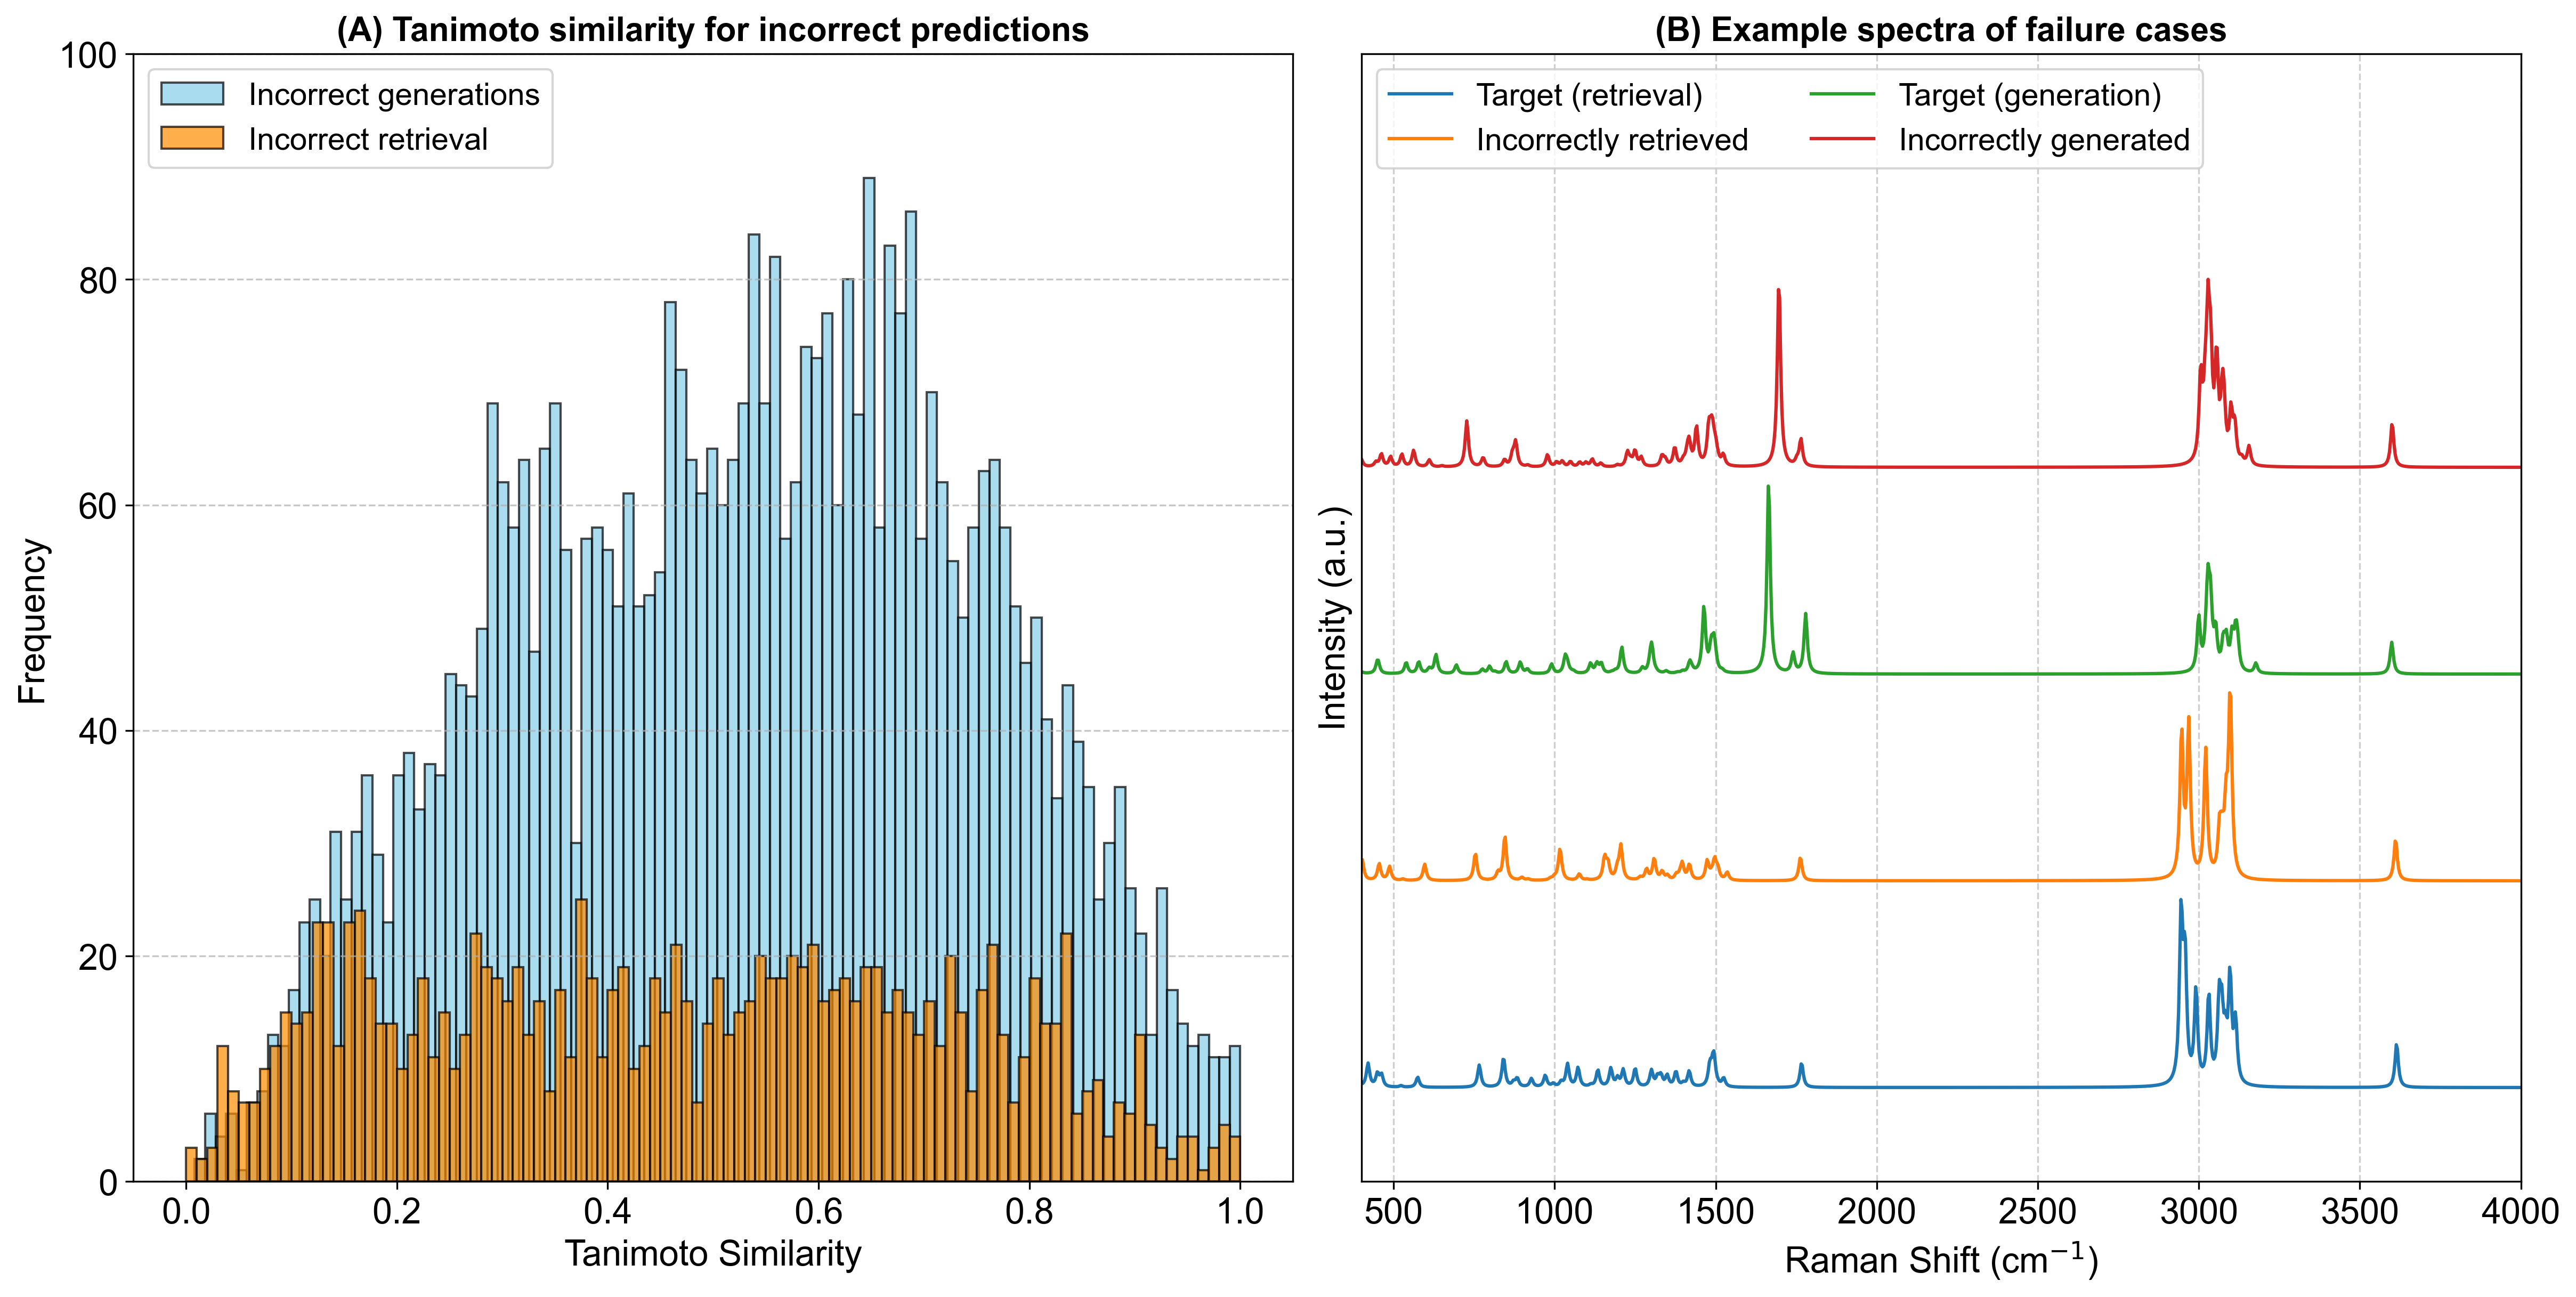

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec

# --- Constants ---
# 字体设置
FONT_PATH = './appendix/Arial.ttf'
DEFAULT_FONT = 'sans-serif'

# 图像整体配置
FIGURE_SIZE = (16, 14)
DPI = 300

# 直方图配置
HIST_BINS = 100
ALPHA_HIST = 0.7

# 散点图配置
ALPHA_hist_TRAINED = 0.1
hist_SIZE = 1

# --- Global Font Sizes ---
fontsize_title = 15
fontsize_label = 16
fontsize_legend = 14
fontsize_ticks = 16
fontsize_data_labels = 12 # Not used in bar charts, but kept for consistency

# --- Font setup (直接在脚本中设置字体) ---
try:
    font_name = fm.FontProperties(fname=FONT_PATH).get_name()
    if font_name not in [f.name for f in fm.fontManager.ttflist]:
        fm.fontManager.addfont(FONT_PATH)
        fm.fontManager.findfont(font_name, rebuild_if_missing=True) # 确保新字体被识别
    plt.rcParams['font.family'] = font_name
    print(f"自定义字体 '{font_name}' 加载成功。")
except FileNotFoundError:
    print(f"警告：字体文件未找到于 '{FONT_PATH}'。使用默认字体 '{DEFAULT_FONT}'。")
    plt.rcParams['font.family'] = DEFAULT_FONT
except Exception as e:
    print(f"警告：无法加载自定义字体。使用默认字体 '{DEFAULT_FONT}'。错误：{e}")
    plt.rcParams['font.family'] = DEFAULT_FONT


height_ratios = [1,] # Slightly more space for radar titles, thinner spacer, and square bottom
width_ratios = [1, 1] # Thinner spacer column
step = 8 # Base unit for scaling the figure
fig = plt.figure(figsize=(step * sum(width_ratios), step * sum(height_ratios)), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 2, height_ratios=height_ratios, width_ratios=width_ratios, figure=fig)

# --- 左下角子图：频数直方图 ---
ax_tanimoto_hist = fig.add_subplot(gs[0, 0])

tanimoto_incorrect_gen = selected_df_gen[selected_df_gen.correct != 1]['tanimoto']
tanimoto_incorrect_ret = df_ret[df_ret.ret_correct != 1]['tanimoto']

ax_tanimoto_hist.hist(tanimoto_incorrect_gen, bins=100, color='skyblue', edgecolor='black', alpha=0.7, label='Incorrect generations')
ax_tanimoto_hist.hist(tanimoto_incorrect_ret, bins=100, color='darkorange', edgecolor='black', alpha=0.7, label='Incorrect retrieval')

ax_tanimoto_hist.set_ylim(0, 100)
ax_tanimoto_hist.set_xlabel('Tanimoto Similarity', fontsize=fontsize_label)
ax_tanimoto_hist.set_ylabel('Frequency', fontsize=fontsize_label)
ax_tanimoto_hist.set_title('(A) Tanimoto similarity for incorrect predictions', fontsize=fontsize_title, fontweight='bold')
ax_tanimoto_hist.grid(axis='y', linestyle='--', alpha=0.7)
ax_tanimoto_hist.legend(fontsize=fontsize_legend, loc='upper left')
ax_tanimoto_hist.tick_params(axis='both', labelsize=fontsize_ticks)



# --- 右下角子图 (目前为空，但已预留空间) ---
ax_spectra = fig.add_subplot(gs[0, 1])
df = pd.read_csv('SI/mols.csv')
df.columns = ['kekule_smiles', 'raman']
x_spectrum = np.linspace(400, 4000, 1024)

ax_spectra.plot(x_spectrum, np.array(eval(df[df['kekule_smiles'] == 'O=CNC1CCCOC1']['raman'].iloc[0])), label='Target (retrieval)')
ax_spectra.plot(x_spectrum, np.array(eval(df[df['kekule_smiles'] == 'O=CNC1CCOCC1']['raman'].iloc[0]))+1.1, label='Incorrectly retrieved')

ax_spectra.plot(x_spectrum, np.array(eval(df[df['kekule_smiles'] == 'CCOC(=O)C1=C(C)NC(=O)CC1']['raman'].iloc[0]))+2.2, label='Target (generation)')
ax_spectra.plot(x_spectrum, np.array(eval(df[df['kekule_smiles'] == 'CCOC(=O)C1=C(C)CC(=O)NC1']['raman'].iloc[0]))+3.3, label='Incorrectly generated')

ax_spectra.set_xlabel('Raman Shift (cm$^{-1}$)', fontsize=fontsize_label)
ax_spectra.set_ylabel('Intensity (a.u.)', fontsize=fontsize_label) # a.u. for arbitrary units
ax_spectra.set_ylim(-0.5, 5.5)
ax_spectra.set_xlim(400, 4000)
ax_spectra.set_title('(B) Example spectra of failure cases',  fontsize=fontsize_title, fontweight='bold')
ax_spectra.tick_params(axis='both', labelsize=fontsize_ticks)
ax_spectra.legend(loc='upper left', fontsize=fontsize_legend, ncol=2)
ax_spectra.grid(True, linestyle='--', alpha=0.6) # Add a grid

# Hide Y-axis ticks and labels if spectra are merely illustrative and absolute intensity isn't crucial
ax_spectra.set_yticks([])
# save
# plt.savefig('tanimoto.svg', dpi=300, bbox_inches='tight')

# Figure 5 chemical reactions

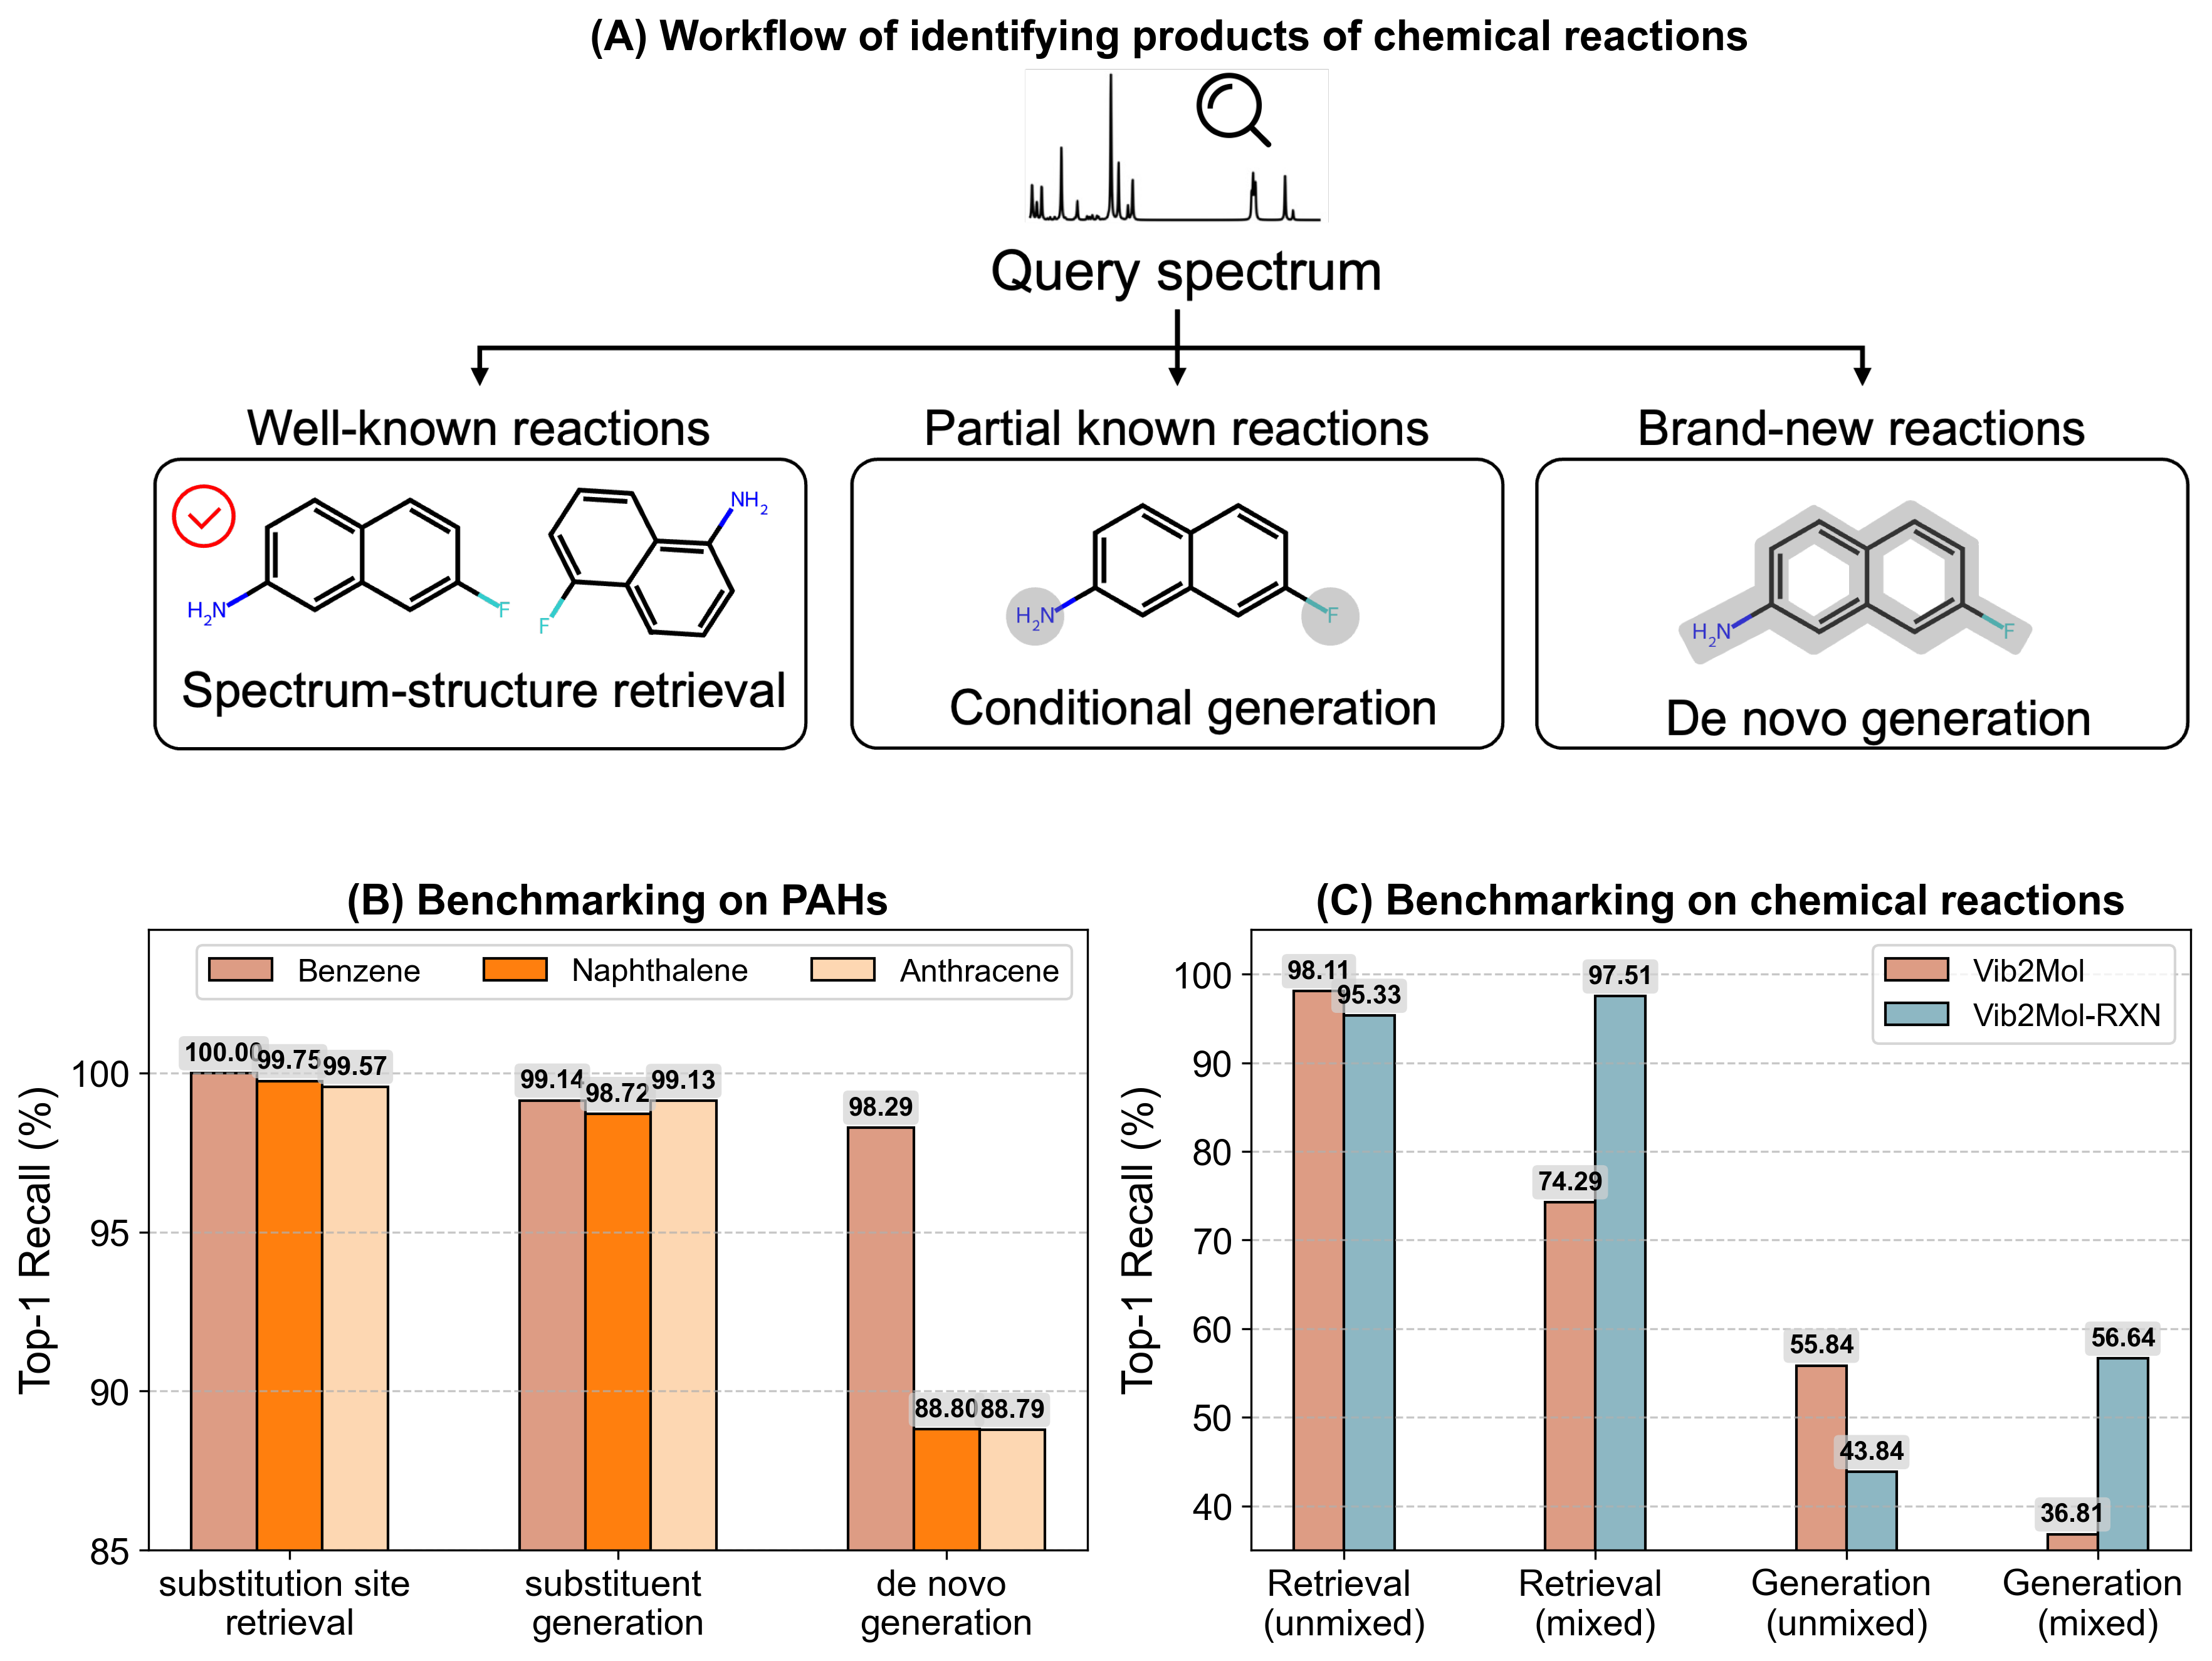

In [ ]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# --- Font Setup ---
font_path = './appendix/Arial.ttf'
try:
    matplotlib.font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
except FileNotFoundError:
    print("Font file not found. Please check the path.")

# --- Global Style and Configuration ---
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'legend.fontsize': 12,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# Create the figure and GridSpec
height_ratios = [1, 0.6] # Slightly more space for radar titles, thinner spacer, and square bottom
width_ratios = [1, 1] # Thinner spacer column
step = 6 # Base unit for scaling the figure
fig = plt.figure(figsize=(step * sum(width_ratios), step * sum(height_ratios)), dpi=300)
gs = GridSpec(2, 2, height_ratios=height_ratios, width_ratios=width_ratios, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')
img = plt.imread('appendix/figure5a.png')
ax1.imshow(img)
ax1.set_title('(A) Workflow of identifying products of chemical reactions', fontsize=plt.rcParams['axes.titlesize'], fontweight='bold')

# --- PAHs Subplot ---
ax_pahs = fig.add_subplot(gs[1, 0])

# PAHs Data
pahs_labels = ['substitution site \nretrieval', 'substituent \ngeneration', 'de novo \ngeneration']
pahs_colors_dict = {
    'Benzene': '#DD9C84', 
    'Naphthalene': '#ff7f0e',
    'Anthracene': '#fdd7b2', 
    # 'Averaged': '#8db7c3',
}
pahs_bar_labels = list(pahs_colors_dict.keys())
# pahs_data = np.array([
#     [100.00, 99.75, 99.57, 99.77],
#     [99.14, 98.72, 99.13, 98.95],
#     [98.29, 88.80, 88.79, 91.39],
# ])

pahs_data = np.array([
    [100.00, 99.75, 99.57, ],
    [99.14, 98.72, 99.13, ],
    [98.29, 88.80, 88.79, ],
])

# Set bar width and positions
bar_width = 0.2
x = np.arange(len(pahs_labels))

# Plot grouped vertical bar chart for PAHs
for i, label in enumerate(pahs_bar_labels):
    offset = i * bar_width - (len(pahs_bar_labels) - 1) * bar_width / 2
    ax_pahs.bar(x + offset, pahs_data[:, i], width=bar_width, label=label,
                color=pahs_colors_dict[label], edgecolor='black')

# Configure PAHs plot
ax_pahs.set_ylabel('Top-1 Recall (%)', fontsize=plt.rcParams['axes.labelsize'])
ax_pahs.set_title('(B) Benchmarking on PAHs', fontsize=plt.rcParams['axes.titlesize'], fontweight='bold')
ax_pahs.set_xticks(x)
ax_pahs.set_xticklabels(pahs_labels, rotation=0, ha='center')
ax_pahs.set_ylim(85, 104.5)
ax_pahs.set_yticks(np.arange(85, 104.5, 5))
ax_pahs.grid(axis='y', linestyle='--', alpha=0.7)
ax_pahs.legend(fontsize=plt.rcParams['legend.fontsize'], loc='upper right', ncol=3)

# Add data labels for PAHs plot
current_bar_index = 0
for i in range(pahs_data.shape[1]):
    for j in range(pahs_data.shape[0]):
        rect = ax_pahs.patches[current_bar_index]
        height = rect.get_height() 
        ax_pahs.annotate(f'{pahs_data[j, i]:.2f}',
                         xy=(rect.get_x() + rect.get_width() / 2, height),
                         xytext=(0, 3),
                         textcoords="offset points",
                         ha='center', va='bottom',
                         fontsize=10, color='black', weight='bold',
                         bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.7))
        current_bar_index += 1

# --- RXN Subplot ---
ax_rxn = fig.add_subplot(gs[1, -1])

# RXN Data
rxn_labels = ['Retrieval \n(unmixed)', 'Retrieval \n(mixed)', 'Generation \n(unmixed)', 'Generation \n(mixed)']
rxn_colors_dict = {'Vib2Mol': '#DD9C84', 'Vib2Mol-RXN': '#8db7c3'}
rxn_bar_labels = list(rxn_colors_dict.keys())
rxn_data = np.array([
    [98.11, 74.29, 55.84, 36.81],
    [95.33, 97.51, 43.84, 56.64],
])

# Set bar width and positions
bar_width = 0.2
x = np.arange(len(rxn_labels))

# Plot grouped vertical bar chart for RXN
for i, label in enumerate(rxn_bar_labels):
    offset = i * bar_width - (len(rxn_bar_labels) - 1) * bar_width / 2
    ax_rxn.bar(x + offset, rxn_data[i, :], width=bar_width, label=label,
                color=rxn_colors_dict[label], edgecolor='black')

# Configure RXN plot
ax_rxn.set_ylabel('Top-1 Recall (%)', fontsize=plt.rcParams['axes.labelsize'])
ax_rxn.set_title('(C) Benchmarking on chemical reactions', fontsize=plt.rcParams['axes.titlesize'], fontweight='bold')
ax_rxn.set_xticks(x)
ax_rxn.set_xticklabels(rxn_labels, rotation=0, ha='center')
ax_rxn.set_ylim(35, 105)
ax_rxn.grid(axis='y', linestyle='--', alpha=0.7)
ax_rxn.legend(fontsize=plt.rcParams['legend.fontsize'])

# Add data labels for RXN plot
current_bar_index = 0
for i in range(rxn_data.shape[0]):
    for j in range(rxn_data.shape[1]):
        rect = ax_rxn.patches[current_bar_index]
        height = rect.get_height() 
        ax_rxn.annotate(f'{height:.2f}',
                         xy=(rect.get_x() + rect.get_width() / 2, height),
                         xytext=(0, 3),
                         textcoords="offset points",
                         ha='center', va='bottom',
                         fontsize=10, color='black', weight='bold',
                         bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.7))
        current_bar_index += 1

plt.tight_layout()
# plt.savefig('Figure5.svg', dpi=300)
plt.show()

# Figure S6 MLM ablation

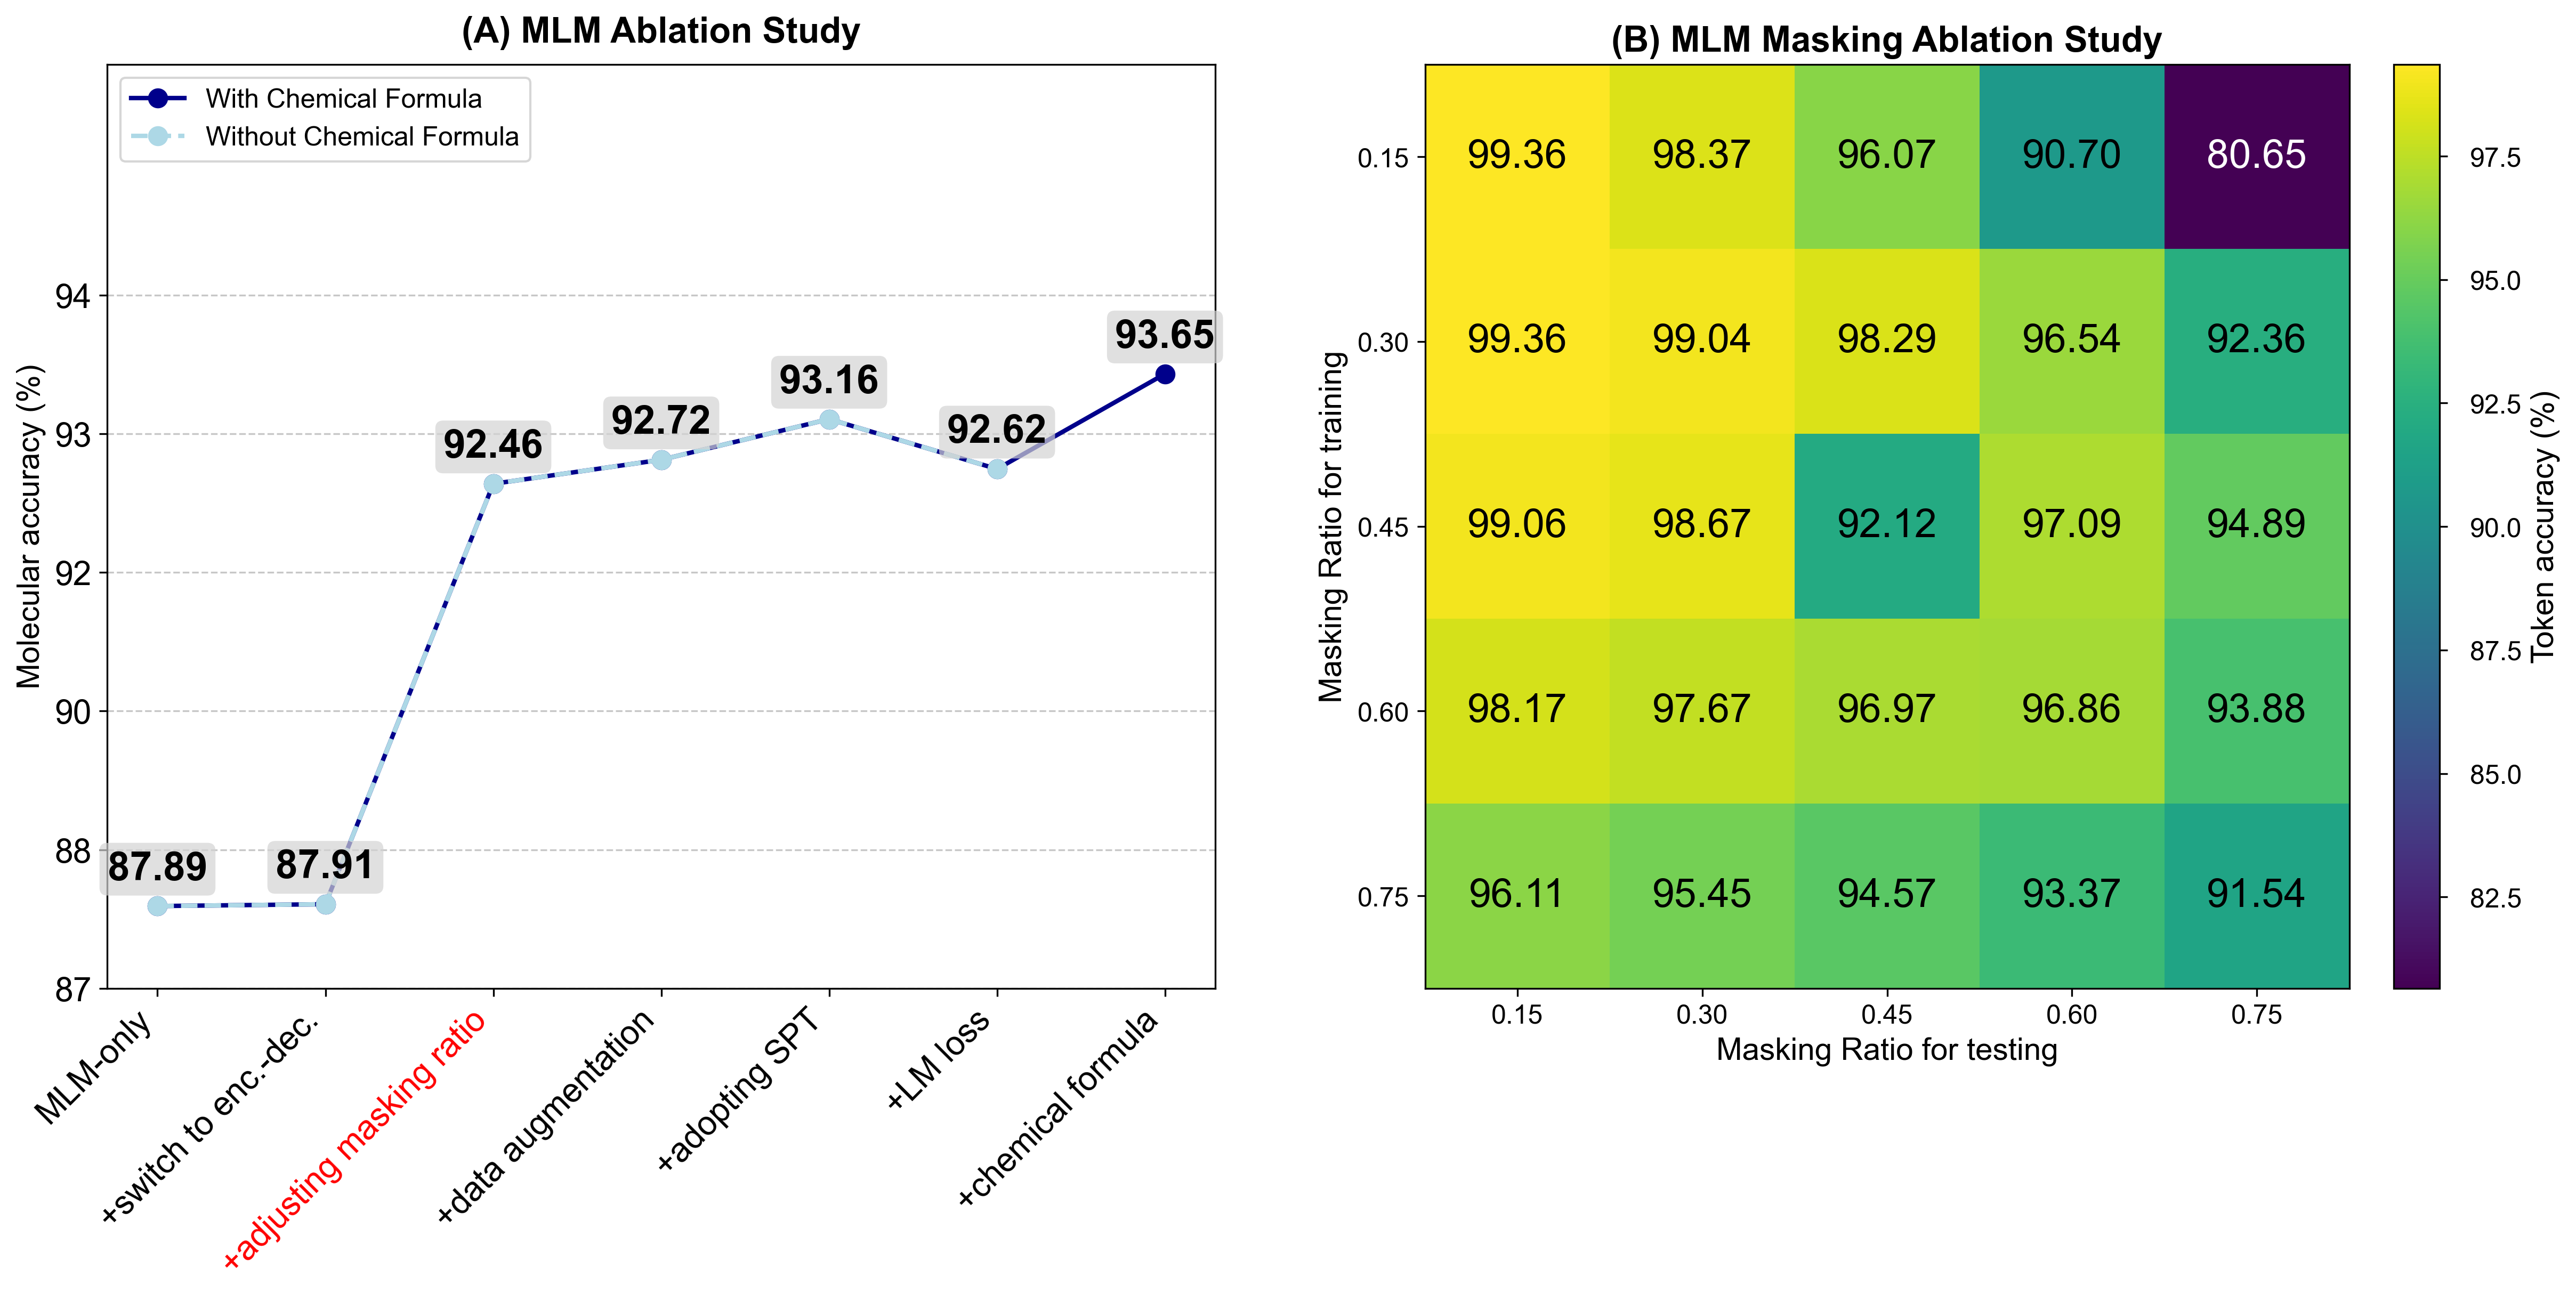

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# --- Font Setup ---
font_path = './appendix/Arial.ttf'
try:
    matplotlib.font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
except FileNotFoundError:
    print("Font file not found. Please check the path.")
    
fontsize_ticks = 15
fontsize_label = 14
fontsize_title = 16
fontsize_legend = 12
fontsize_data_labels = 18 # Not used in bar charts, but kept for consistency

height_ratios = [1, ] # Slightly more space for radar titles, thinner spacer, and square bottom
width_ratios = [1, 1] # Thinner spacer column
step = 8 # Base unit for scaling the figure
fig = plt.figure(figsize=(step * sum(width_ratios), step * sum(height_ratios)), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 2, height_ratios=height_ratios, width_ratios=width_ratios, figure=fig)


ax1 = fig.add_subplot(gs[0, 0])
# --- Data Preparation for Line Chart ---
mlm_ablation_labels = [
    'MLM-only',
    '+switch to enc.-dec.',
    '+adjusting masking ratio',
    '+data augmentation',
    '+adopting SPT',
    '+LM loss',
    '+chemical formula',
]

# Data for the ablation study
mlm_ablation_values = np.array([87.89, 87.91, 92.46, 92.72, 93.16, 92.62, 93.65])
mlm_ablation_values_comp = np.array([87.89, 87.91, 92.46, 92.72, 93.16, 92.62, np.nan])


ax1.plot(mlm_ablation_labels, mlm_ablation_values, marker='o', linestyle='-', color='darkblue', linewidth=2, markersize=8, label='With Chemical Formula')
ax1.plot(mlm_ablation_labels, mlm_ablation_values_comp, marker='o', linestyle='--', color='lightblue', linewidth=2, markersize=8, label='Without Chemical Formula')

ax1.set_xticks(range(len(mlm_ablation_labels)))
ax1.set_xticklabels(mlm_ablation_labels, rotation=45, ha='right', fontsize=fontsize_ticks)
# set '+adjusting masking ratio' as red
ax1.get_xticklabels()[2].set_color('red')

min_val = np.floor(np.min(mlm_ablation_values) / 1.5) * 1.5
max_val = np.ceil(np.max(mlm_ablation_values) / 1.5) * 1.5
ax1.set_yticks(np.arange(min_val, max_val + 1.5, 1.5))
ax1.set_yticklabels([f'{y:.0f}' for y in ax1.get_yticks()], fontsize=fontsize_ticks)

ax1.set_ylim(87, 97)
ax1.set_ylabel('Molecular accuracy (%)', fontsize=fontsize_label)
ax1.set_title('(A) MLM Ablation Study', fontsize=fontsize_title, fontweight='bold', pad=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(mlm_ablation_values):
    ax1.text(i, value + 0.2, f'{value:.2f}', ha='center', va='bottom', fontsize=fontsize_data_labels, color='black', weight='bold',  # Bold black text
                  bbox=dict(boxstyle="round,pad=0.2", fc="lightgrey", ec="none", alpha=0.7)) # Grey background

ax1.legend(fontsize=fontsize_legend, loc='upper left', frameon=True) # Position legend



ax2 = fig.add_subplot(gs[0, 1])

mlm_mask_ablation_values = np.array([
    [99.36, 98.37, 96.07, 90.70, 80.65],
    [99.36, 99.04, 98.29, 96.54, 92.36],
    [99.06, 98.67, 92.12, 97.09, 94.89],
    [98.17, 97.67, 96.97, 96.86, 93.88],
    [96.11, 95.45, 94.57, 93.37, 91.54],
])

ax2.imshow(mlm_mask_ablation_values, cmap='viridis', aspect='auto')
ax2.set_xticks(ticks=np.arange(5), labels=['0.15', '0.30', '0.45', '0.60', '0.75'], fontsize=12)
ax2.set_yticks(ticks=np.arange(5), labels=['0.15', '0.30', '0.45', '0.60', '0.75'], fontsize=12)
ax2.set_xlabel('Masking Ratio for testing', fontsize=14)
ax2.set_ylabel('Masking Ratio for training', fontsize=14)
ax2.set_title('(B) MLM Masking Ablation Study', fontsize=16, fontweight='bold')
# set box as an square
ax2.set_box_aspect(1)  # Set aspect ratio to be equal
ax2.grid(False)  # Disable grid
# set colorbar with the same aspect ratio
ax2.set_aspect('equal', adjustable='box')

cbar = plt.colorbar(ax2.images[0], ax=ax2, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Token accuracy (%)', fontsize=14)
cbar.ax.tick_params(labelsize=12, pad=10)  # set font size for colorbar's ticks
# set cbar fraction=0.046, pad=0.04

# plt.tight_layout()

for i in range(5):
    for j in range(5):
        color = 'white' if mlm_mask_ablation_values[i, j] < 90 else 'black'
        plt.text(j, i, f'{mlm_mask_ablation_values[i, j]:.2f}', ha='center', va='center', color=color, fontsize=fontsize_data_labels)

# plt.savefig('mlm_mask_ablation.svg', dpi=300, bbox_inches='tight')